# Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy.stats import shapiro, normaltest
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, log_loss, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
)

from lightgbm import LGBMClassifier

from collections import defaultdict

/home/antonio/projetos/fase-5/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Funções úteis

### verificar_normalidade

In [2]:
def verificar_normalidade(data_series, feature_name, alpha=0.05):
    """
    Aplica os testes de Shapiro-Wilk e D'Agostino's K-squared a uma série de dados
    e imprime uma conclusão sobre sua normalidade.

    Args:
        data_series (pd.Series): A série de dados (coluna do DataFrame) a ser testada.
        feature_name (str): O nome da feature para impressão.
        alpha (float): O nível de significância para o teste.
    """
    print(f"--- Análise de Normalidade para a Feature: '{feature_name}' ---")

    # 1. Teste de Shapiro-Wilk
    stat_shapiro, p_shapiro = shapiro(data_series)
    print(f"\n1. Teste de Shapiro-Wilk:")
    print(f"   - Estatística do teste = {stat_shapiro:.4f}")
    print(f"   - P-valor = {p_shapiro:.4f}")
    if p_shapiro > alpha:
        print(f"   - Conclusão (alpha={alpha}): Não há evidência para rejeitar a normalidade (Normal).")
    else:
        print(f"   - Conclusão (alpha={alpha}): A hipótese de normalidade é rejeitada (Não Normal).")

    # 2. Teste de D'Agostino's K-squared
    stat_k2, p_k2 = normaltest(data_series)
    print(f"\n2. Teste de D'Agostino's K-squared:")
    print(f"   - Estatística do teste = {stat_k2:.4f}")
    print(f"   - P-valor = {p_k2:.4f}")
    if p_k2 > alpha:
        print(f"   - Conclusão (alpha={alpha}): Não há evidência para rejeitar a normalidade (Normal).")
    else:
        print(f"   - Conclusão (alpha={alpha}): A hipótese de normalidade é rejeitada (Não Normal).")

    print("-" * 50 + "\n")

### aplicar_transformacao_log

In [3]:
def aplicar_transformacao_log(df, colunas):
    """
    Aplica a transformação logarítmica (log1p) a uma lista de colunas
    de um DataFrame e cria novas colunas com o sufixo '_log'.

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        colunas (list): Uma lista de nomes de colunas para transformar.

    Returns:
        pd.DataFrame: O DataFrame com as novas colunas transformadas.
    """
    df_transformado = df.copy()
    #new_columns = []
    for col in colunas:
        # Verifica se a coluna existe no DataFrame
        if col in df_transformado.columns:
            df_transformado[col + '_log'] = np.log1p(df_transformado[col])
            #new_columns.append(col + '_log')
        else:
            print(f"Aviso: A coluna '{col}' não foi encontrada no DataFrame.")

    return df_transformado

### perform_cross_validation

In [4]:
def perform_cross_validation(X_train, y_train, skf, model):
    """
    Realiza validação cruzada estratificada para CLASSIFICAÇÃO BINÁRIA.

    Para cada fold, treina o modelo fornecido com escalonamento de features,
    calcula predições e probabilidades, e retorna um dicionário com as métricas
    de desempenho tanto para o conjunto de treino quanto para o de validação.

    Parameters
    ----------
    X_train : pd.DataFrame or np.ndarray
        Features do conjunto de treinamento.
    y_train : pd.Series or np.ndarray
        Labels do conjunto de treinamento (binários: 0 ou 1).
        Classe positiva (1) representa evasão do aluno.
    skf : StratifiedKFold
        Objeto StratifiedKFold configurado.
    model : estimator object
        Instância do modelo de classificação a ser treinado.

    Returns
    -------
    results : dict
        Dicionário contendo as listas de métricas calculadas para cada fold.
        Estrutura: results[dataset][metric] = [valores por fold]
    """
    
    # Dicionário para armazenar os resultados
    results = defaultdict(lambda: defaultdict(list))
    
    n_splits = skf.get_n_splits()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        print(f"\n{'='*60}")
        print(f"Processando Fold {fold}/{n_splits}")
        print(f"{'='*60}")

        # Divisão dos dados do fold (usando indexação que funciona para pandas e numpy)
        if isinstance(X_train, pd.DataFrame):
            X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        else:
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]

        if isinstance(y_train, pd.Series):
            y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        else:
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Escalonamento das features
        scaler = StandardScaler()
        
        if isinstance(X_train, pd.DataFrame):
            X_train_fold_scaled = pd.DataFrame(
                scaler.fit_transform(X_train_fold),
                columns=X_train_fold.columns,
                index=X_train_fold.index
            )
            X_val_fold_scaled = pd.DataFrame(
                scaler.transform(X_val_fold),
                columns=X_val_fold.columns,
                index=X_val_fold.index
            )
        else:
            X_train_fold_scaled = scaler.fit_transform(X_train_fold)
            X_val_fold_scaled = scaler.transform(X_val_fold)

        # Treinamento do modelo
        model.fit(X_train_fold_scaled, y_train_fold)

        # Predições e Probabilidades
        datasets = {
            'train': (y_train_fold, X_train_fold_scaled),
            'validation': (y_val_fold, X_val_fold_scaled)
        }

        # Cálculo e Armazenamento das Métricas
        for name, (y_true, X_scaled) in datasets.items():
            # Predições
            y_pred = model.predict(X_scaled)
            y_proba = model.predict_proba(X_scaled)
            
            # Para classificação binária: extrair probabilidade da classe positiva (coluna 1)
            y_proba_pos = y_proba[:, 1]

            # Calculando as métricas para classificação binária
            acc = accuracy_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred, pos_label=1)
            recall = recall_score(y_true, y_pred, pos_label=1)
            precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            loss = log_loss(y_true, y_proba)  # Log loss (menor é melhor)
            roc = roc_auc_score(y_true, y_proba_pos)  # ROC-AUC binário
            pr_auc = average_precision_score(y_true, y_proba_pos)  # PR-AUC binário

            # Armazenando os resultados
            results[name]['accuracy'].append(acc)
            results[name]['f1_score'].append(f1)
            results[name]['recall'].append(recall)
            results[name]['precision'].append(precision)
            results[name]['log_loss'].append(loss)
            results[name]['roc_auc'].append(roc)
            results[name]['pr_auc'].append(pr_auc)
        
        # Exibir métricas do fold atual
        print(f"\nTrain      - Acc: {results['train']['accuracy'][-1]:.4f} | "
              f"F1: {results['train']['f1_score'][-1]:.4f} | "
              f"ROC-AUC: {results['train']['roc_auc'][-1]:.4f}")
        print(f"Validation - Acc: {results['validation']['accuracy'][-1]:.4f} | "
              f"F1: {results['validation']['f1_score'][-1]:.4f} | "
              f"ROC-AUC: {results['validation']['roc_auc'][-1]:.4f}")

    print(f"\n{'='*60}")
    print("✅ Validação Cruzada concluída!")
    print(f"{'='*60}")
    
    return dict(results)

### analise_nulos

In [5]:
def analise_nulos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera um relatório contendo a quantidade e a porcentagem de valores nulos por coluna.

    Args:
        df (pd.DataFrame): O DataFrame a ser analisado.

    Returns:
        pd.DataFrame: Um DataFrame contendo as colunas 'nome_coluna', 'qtd_nulos' 
                      e 'porcentagem_nulos', ordenado decrescentemente pela quantidade de nulos.
    """
    # Cálculo das métricas
    nulos = df.isnull().sum()
    porcentagem = ((nulos / len(df)) * 100).round(2)
    
    # Criação do DataFrame de resumo
    df_nulos = pd.DataFrame({
        'qtd_nulos': nulos,
        'porcentagem_nulos': porcentagem
    })
    
    # Ajuste do índice para se tornar uma coluna
    df_nulos.reset_index(inplace=True)
    df_nulos.rename(columns={'index': 'nome_coluna'}, inplace=True)
    
    # Ordenação
    df_nulos.sort_values(by='qtd_nulos', ascending=False, inplace=True)
    
    return df_nulos

# Loading data

In [6]:
data_dir = '../data/processed'
file_name_2022 = 'df_model_2022.csv'
file_path_2022 = os.path.join(data_dir, file_name_2022)

file_name_2023 = 'df_model_2023.csv'
file_path_2023 = os.path.join(data_dir, file_name_2023)

file_name_concatenado = 'df_model_concatenado.csv'
file_path_concatenado = os.path.join(data_dir, file_name_concatenado)

df_loaded = pd.read_csv(file_path_2023)
df_loaded.head()

,RA,FASE_23,NOVA_TURMA_23,DEFASAGEM_23,NOVA_FASE_IDEAL_23,NOVA_IDADE_2023,GÊNERO_23,ANO_INGRESSO_23,INSTITUICAO_ENSINO_23,VETERANO_23,EM_FASE_23,QTDE_AVAL_2023,IAA_23,IEG_23,IPS_23,IDA_23,IPV_23,IAN_23,EVADIU
0,RA-1000,Fase 0,U,0.0,Fase 0,8.0,1.0,2023.0,Pública,0.0,1.0,2.0,8.5,9.4,3.77,7.0,8.92,10.0,0.0
1,RA-1001,Fase 0,U,-1.0,Fase 1,9.0,1.0,2023.0,Pública,0.0,0.0,2.0,9.0,9.1,7.52,7.8,9.17,5.0,0.0
2,RA-1002,Fase 0,U,-1.0,Fase 1,9.0,1.0,2023.0,Pública,0.0,0.0,2.0,9.0,9.7,7.52,7.0,8.92,5.0,0.0
3,RA-1003,Fase 0,V,0.0,Fase 0,8.0,0.0,2023.0,Pública,0.0,1.0,2.0,9.0,8.5,7.52,4.0,8.75,10.0,0.0
4,RA-1004,Fase 0,V,0.0,Fase 0,9.0,1.0,2023.0,Pública,0.0,1.0,2.0,9.0,9.6,7.52,7.9,7.42,10.0,0.0


In [7]:
df_loaded.info()

<class 'pandas.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     923 non-null    str    
 1   FASE_23                923 non-null    str    
 2   NOVA_TURMA_23          923 non-null    str    
 3   DEFASAGEM_23           923 non-null    float64
 4   NOVA_FASE_IDEAL_23     923 non-null    str    
 5   NOVA_IDADE_2023        923 non-null    float64
 6   GÊNERO_23              923 non-null    float64
 7   ANO_INGRESSO_23        923 non-null    float64
 8   INSTITUICAO_ENSINO_23  923 non-null    str    
 9   VETERANO_23            923 non-null    float64
 10  EM_FASE_23             923 non-null    float64
 11  QTDE_AVAL_2023         923 non-null    float64
 12  IAA_23                 923 non-null    float64
 13  IEG_23                 923 non-null    float64
 14  IPS_23                 923 non-null    float64
 15  IDA_23           

## numerical and categorical features

In [8]:
target = df_loaded[['EVADIU']].astype('int64')
num_features = df_loaded.select_dtypes(['float64','int64']).drop(columns=['EVADIU']).columns.tolist()
categorical_features = df_loaded.select_dtypes(['object','category','str']).columns.tolist()

In [9]:
df_loaded[num_features].head()

,DEFASAGEM_23,NOVA_IDADE_2023,GÊNERO_23,ANO_INGRESSO_23,VETERANO_23,EM_FASE_23,QTDE_AVAL_2023,IAA_23,IEG_23,IPS_23,IDA_23,IPV_23,IAN_23
0,0.0,8.0,1.0,2023.0,0.0,1.0,2.0,8.5,9.4,3.77,7.0,8.92,10.0
1,-1.0,9.0,1.0,2023.0,0.0,0.0,2.0,9.0,9.1,7.52,7.8,9.17,5.0
2,-1.0,9.0,1.0,2023.0,0.0,0.0,2.0,9.0,9.7,7.52,7.0,8.92,5.0
3,0.0,8.0,0.0,2023.0,0.0,1.0,2.0,9.0,8.5,7.52,4.0,8.75,10.0
4,0.0,9.0,1.0,2023.0,0.0,1.0,2.0,9.0,9.6,7.52,7.9,7.42,10.0


In [10]:
df_loaded[categorical_features].head()

,RA,FASE_23,NOVA_TURMA_23,NOVA_FASE_IDEAL_23,INSTITUICAO_ENSINO_23
0,RA-1000,Fase 0,U,Fase 0,Pública
1,RA-1001,Fase 0,U,Fase 1,Pública
2,RA-1002,Fase 0,U,Fase 1,Pública
3,RA-1003,Fase 0,V,Fase 0,Pública
4,RA-1004,Fase 0,V,Fase 0,Pública


In [11]:
df_loaded[categorical_features]['FASE_23'].value_counts()

FASE_23
Fase 0    231
Fase 2    199
Fase 1    173
Fase 3    132
Fase 4     87
Fase 5     64
Fase 6     31
Fase 7      6
Name: count, dtype: int64

In [12]:
df_loaded[categorical_features]['NOVA_FASE_IDEAL_23'].value_counts()

NOVA_FASE_IDEAL_23
Fase 2    246
Fase 3    203
Fase 0    116
Fase 1    108
Fase 4     94
Fase 5     58
Fase 6     49
Fase 7     40
Fase 8      9
Name: count, dtype: int64

In [13]:
df_loaded[categorical_features]['INSTITUICAO_ENSINO_23'].value_counts()

INSTITUICAO_ENSINO_23
Pública    802
Privada    121
Name: count, dtype: int64

In [14]:
df_loaded[categorical_features]['NOVA_TURMA_23'].value_counts()

NOVA_TURMA_23
A    102
L     93
M     74
B     67
F     64
C     60
G     60
K     57
N     52
D     41
P     37
H     35
R     34
J     26
U     24
I     22
O     13
E     12
Q     12
S     12
T     11
V      9
Y      6
Name: count, dtype: int64

# Tratamento de dados inicial

## Feature 'INSTITUICAO_ENSINO_23'

In [15]:
map_instituicao = {'Pública' : 1,
                   'Privada': 0}
df_loaded['INSTITUICAO_ENSINO_23_mapped'] = df_loaded['INSTITUICAO_ENSINO_23'].map(map_instituicao)
df_loaded['INSTITUICAO_ENSINO_23_mapped'].value_counts()


INSTITUICAO_ENSINO_23_mapped
1    802
0    121
Name: count, dtype: int64

## Amostras duplicadas

In [16]:
# Identificando presença de valores repetidos
df_loaded[df_loaded.duplicated()]

,RA,FASE_23,NOVA_TURMA_23,DEFASAGEM_23,NOVA_FASE_IDEAL_23,NOVA_IDADE_2023,GÊNERO_23,ANO_INGRESSO_23,INSTITUICAO_ENSINO_23,VETERANO_23,EM_FASE_23,QTDE_AVAL_2023,IAA_23,IEG_23,IPS_23,IDA_23,IPV_23,IAN_23,EVADIU,INSTITUICAO_ENSINO_23_mapped


# Análise Exploratória de Dados (EDA)

In [17]:
num_features = df_loaded.select_dtypes(['float64','int64']).drop(columns=['EVADIU']).columns.tolist()
df_loaded[num_features].describe([.1, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
DEFASAGEM_23,923.0,-0.712893,0.800567,-4.00,-2.00,-1.0000,-1.0000,0.00,0.000000,0.0000,1.000,2.00
NOVA_IDADE_2023,923.0,11.878657,2.682475,7.00,8.00,10.0000,12.0000,14.00,16.000000,17.0000,18.000,19.00
GÊNERO_23,923.0,0.527627,0.499507,0.00,0.00,0.0000,1.0000,1.00,1.000000,1.0000,1.000,1.00
ANO_INGRESSO_23,923.0,2021.459372,1.842858,2016.00,2019.00,2021.0000,2022.0000,2023.00,2023.000000,2023.0000,2023.000,2023.00
VETERANO_23,923.0,0.614301,0.487024,0.00,0.00,0.0000,1.0000,1.00,1.000000,1.0000,1.000,1.00
EM_FASE_23,923.0,0.384615,0.486768,0.00,0.00,0.0000,0.0000,1.00,1.000000,1.0000,1.000,1.00
QTDE_AVAL_2023,923.0,3.096425,0.767011,2.00,2.00,2.5000,3.0000,4.00,4.000000,4.0000,4.000,4.00
IAA_23,923.0,6.894366,3.604298,0.00,0.00,6.7000,8.5000,9.20,9.600000,10.0000,10.000,10.00
IEG_23,923.0,8.699242,1.083203,3.70,7.30,8.1000,9.0000,9.50,9.800000,9.9000,10.000,10.00
IPS_23,923.0,5.134410,2.093280,2.52,2.52,2.5200,5.0000,7.52,7.520000,7.5200,8.140,10.00


## Análise univariada

### Feature DEFASAGEM_23

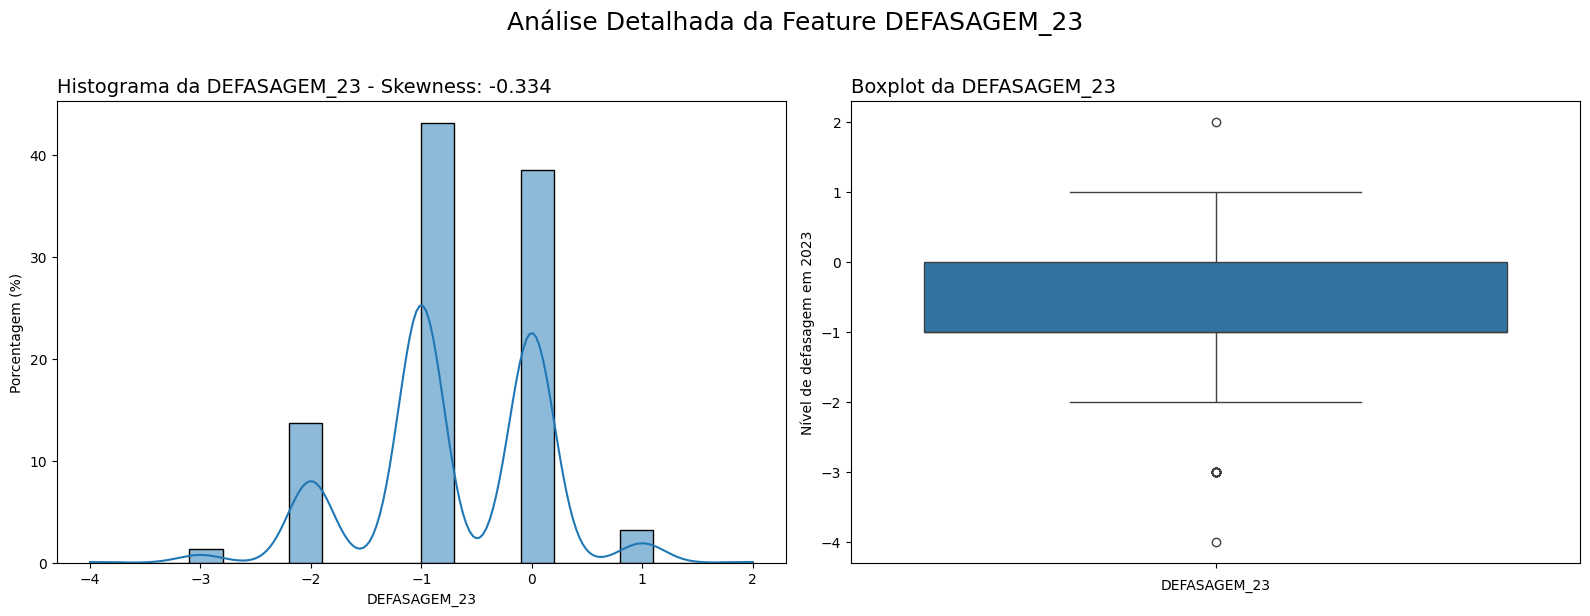

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['DEFASAGEM_23'].skew()

# Histograma
sns.histplot(df_loaded['DEFASAGEM_23'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da DEFASAGEM_23 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('DEFASAGEM_23')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['DEFASAGEM_23'], ax=axes[1])
axes[1].set_title('Boxplot da DEFASAGEM_23', fontsize=14, loc='left')
axes[1].set_ylabel('Nível de defasagem em 2023')
axes[1].set_xlabel('DEFASAGEM_23')

plt.suptitle('Análise Detalhada da Feature DEFASAGEM_23', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['DEFASAGEM_23'], 'DEFASAGEM_23')

--- Análise de Normalidade para a Feature: 'DEFASAGEM_23' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.8606
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 17.7108
   - P-valor = 0.0001
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IDADE_2023

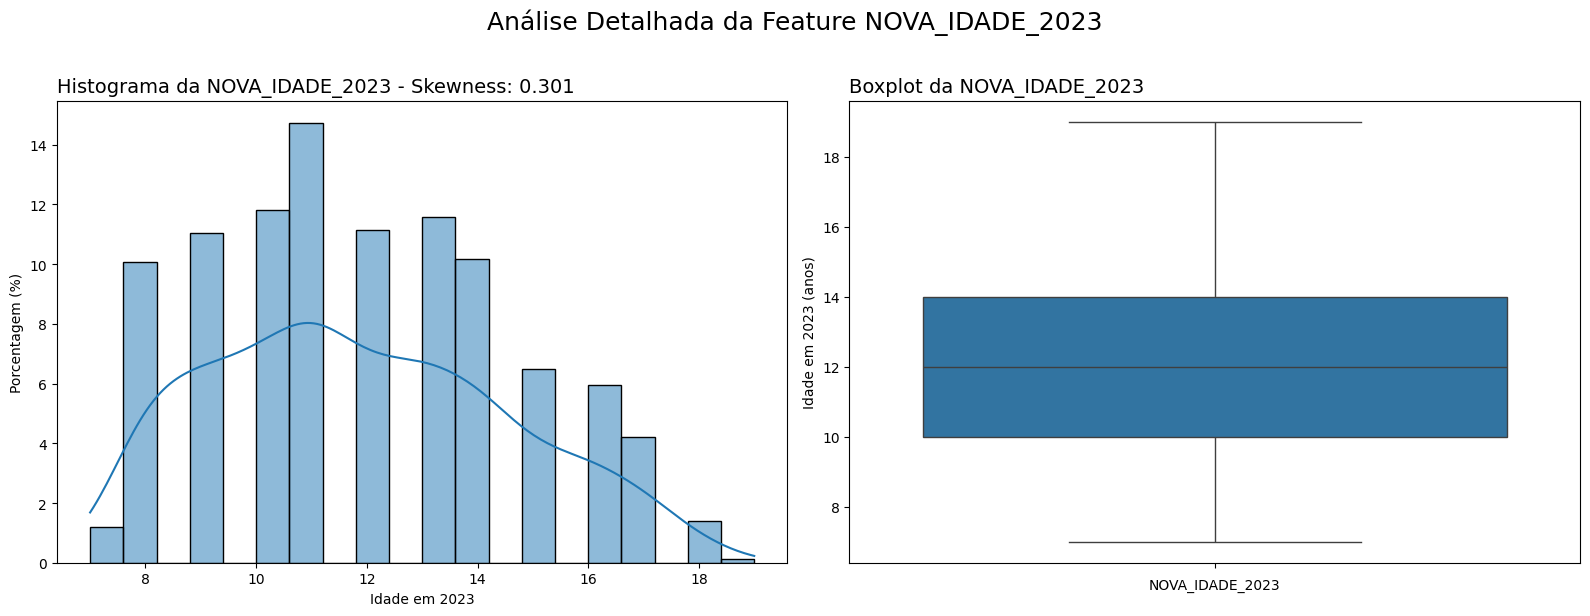

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['NOVA_IDADE_2023'].skew()

# Histograma
sns.histplot(df_loaded['NOVA_IDADE_2023'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da NOVA_IDADE_2023 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('Idade em 2023')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['NOVA_IDADE_2023'], ax=axes[1])
axes[1].set_title('Boxplot da NOVA_IDADE_2023', fontsize=14, loc='left')
axes[1].set_ylabel('Idade em 2023 (anos)')
axes[1].set_xlabel('NOVA_IDADE_2023')

plt.suptitle('Análise Detalhada da Feature NOVA_IDADE_2023', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['NOVA_IDADE_2023'], 'NOVA_IDADE_2023')

--- Análise de Normalidade para a Feature: 'NOVA_IDADE_2023' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.9618
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 74.2514
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature ANO_INGRESSO_23

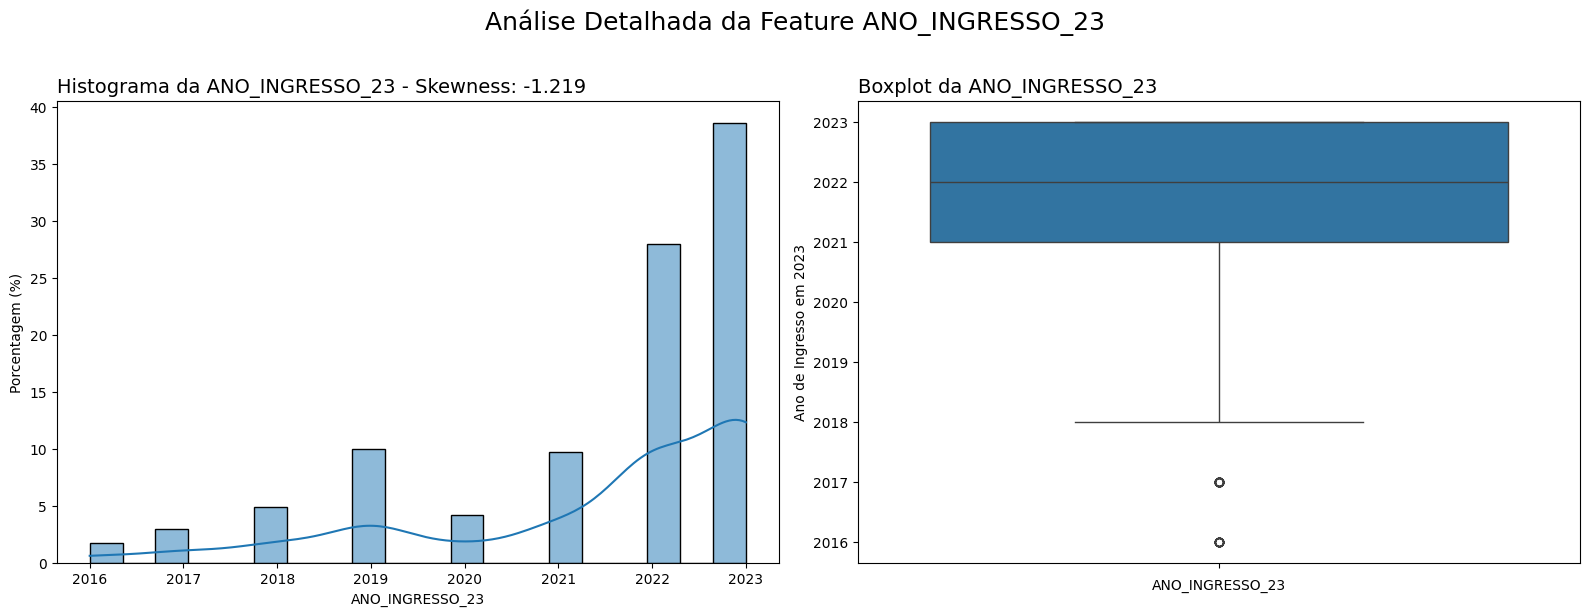

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['ANO_INGRESSO_23'].skew()

# Histograma
sns.histplot(df_loaded['ANO_INGRESSO_23'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da ANO_INGRESSO_23 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('ANO_INGRESSO_23')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['ANO_INGRESSO_23'], ax=axes[1])
axes[1].set_title('Boxplot da ANO_INGRESSO_23', fontsize=14, loc='left')
axes[1].set_ylabel('Ano de Ingresso em 2023')
axes[1].set_xlabel('ANO_INGRESSO_23')

plt.suptitle('Análise Detalhada da Feature ANO_INGRESSO_23', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['ANO_INGRESSO_23'], 'ANO_INGRESSO_23')

--- Análise de Normalidade para a Feature: 'ANO_INGRESSO_23' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.7938
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 154.9432
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature QTDE_AVAL_2023

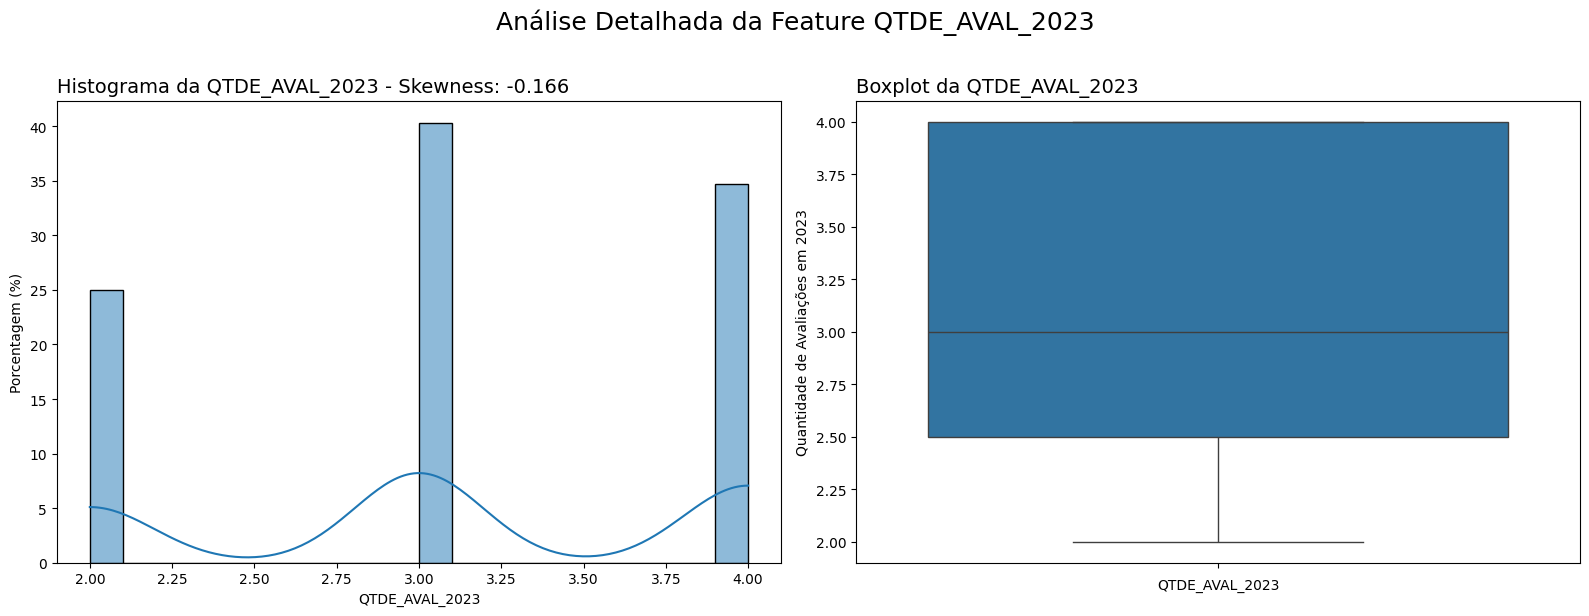

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['QTDE_AVAL_2023'].skew()

# Histograma
sns.histplot(df_loaded['QTDE_AVAL_2023'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da QTDE_AVAL_2023 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('QTDE_AVAL_2023')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['QTDE_AVAL_2023'], ax=axes[1])
axes[1].set_title('Boxplot da QTDE_AVAL_2023', fontsize=14, loc='left')
axes[1].set_ylabel('Quantidade de Avaliações em 2023')
axes[1].set_xlabel('QTDE_AVAL_2023')

plt.suptitle('Análise Detalhada da Feature QTDE_AVAL_2023', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['QTDE_AVAL_2023'], 'QTDE_AVAL_2023')

--- Análise de Normalidade para a Feature: 'QTDE_AVAL_2023' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.8032
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 1531.6050
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IAA_23

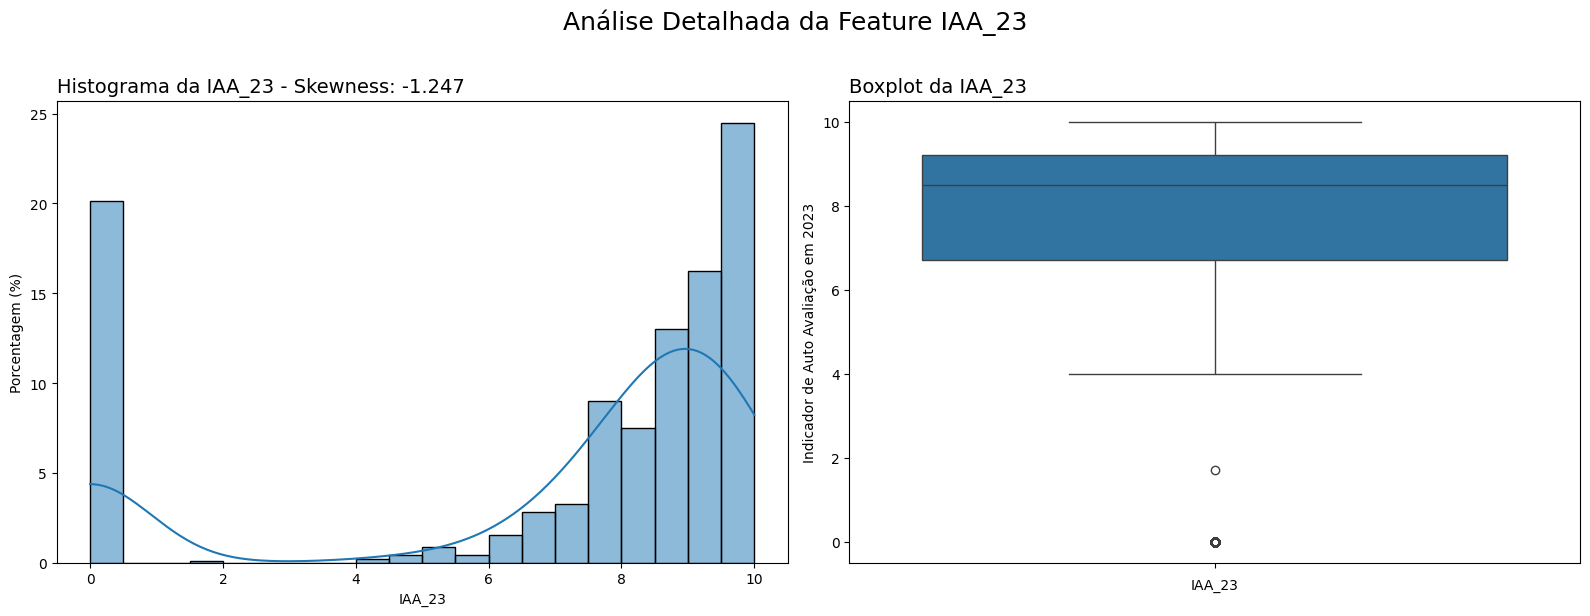

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IAA_23'].skew()

# Histograma
sns.histplot(df_loaded['IAA_23'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IAA_23 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IAA_23')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IAA_23'], ax=axes[1])
axes[1].set_title('Boxplot da IAA_23', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Auto Avaliação em 2023')
axes[1].set_xlabel('IAA_23')

plt.suptitle('Análise Detalhada da Feature IAA_23', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IAA_23'], 'IAA_23')

--- Análise de Normalidade para a Feature: 'IAA_23' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.7013
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 154.2547
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IEG_23

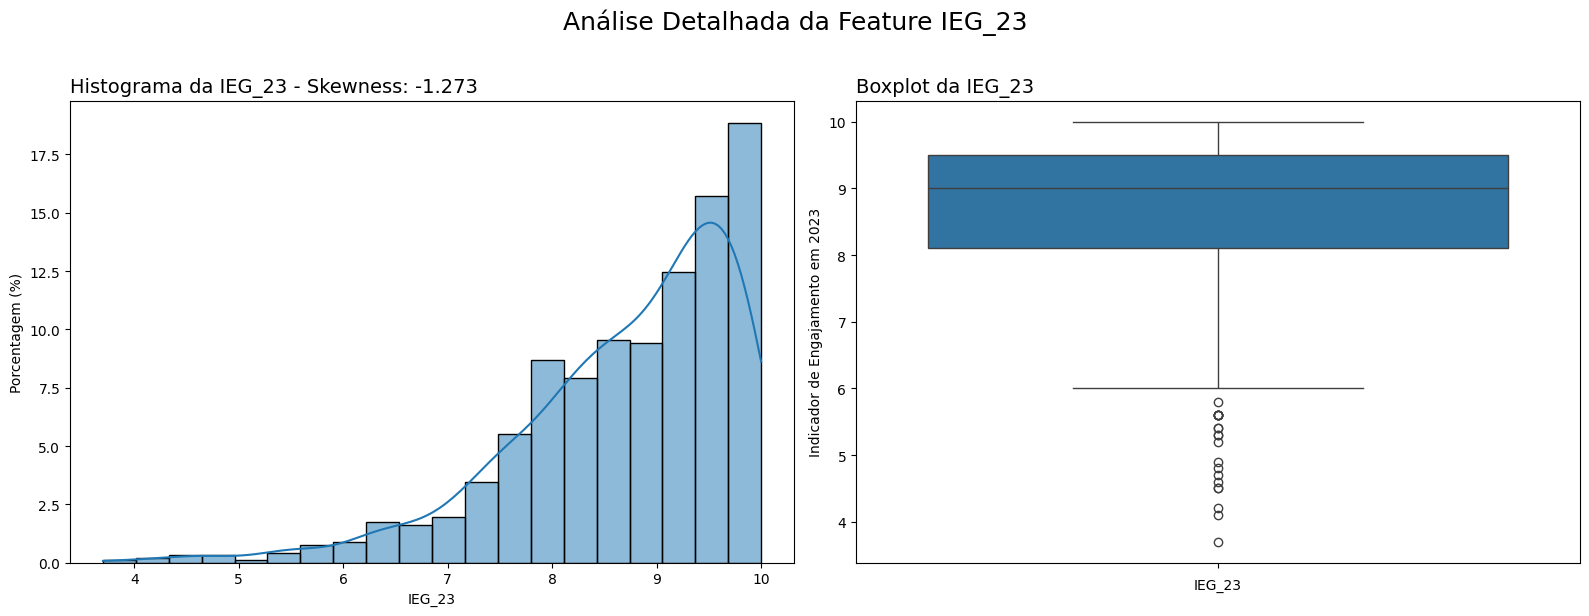

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IEG_23'].skew()

# Histograma
sns.histplot(df_loaded['IEG_23'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IEG_23 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IEG_23')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IEG_23'], ax=axes[1])
axes[1].set_title('Boxplot da IEG_23', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Engajamento em 2023')
axes[1].set_xlabel('IEG_23')

plt.suptitle('Análise Detalhada da Feature IEG_23', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IEG_23'], 'IEG_23')

--- Análise de Normalidade para a Feature: 'IEG_23' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.8982
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 201.4872
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IPS_23

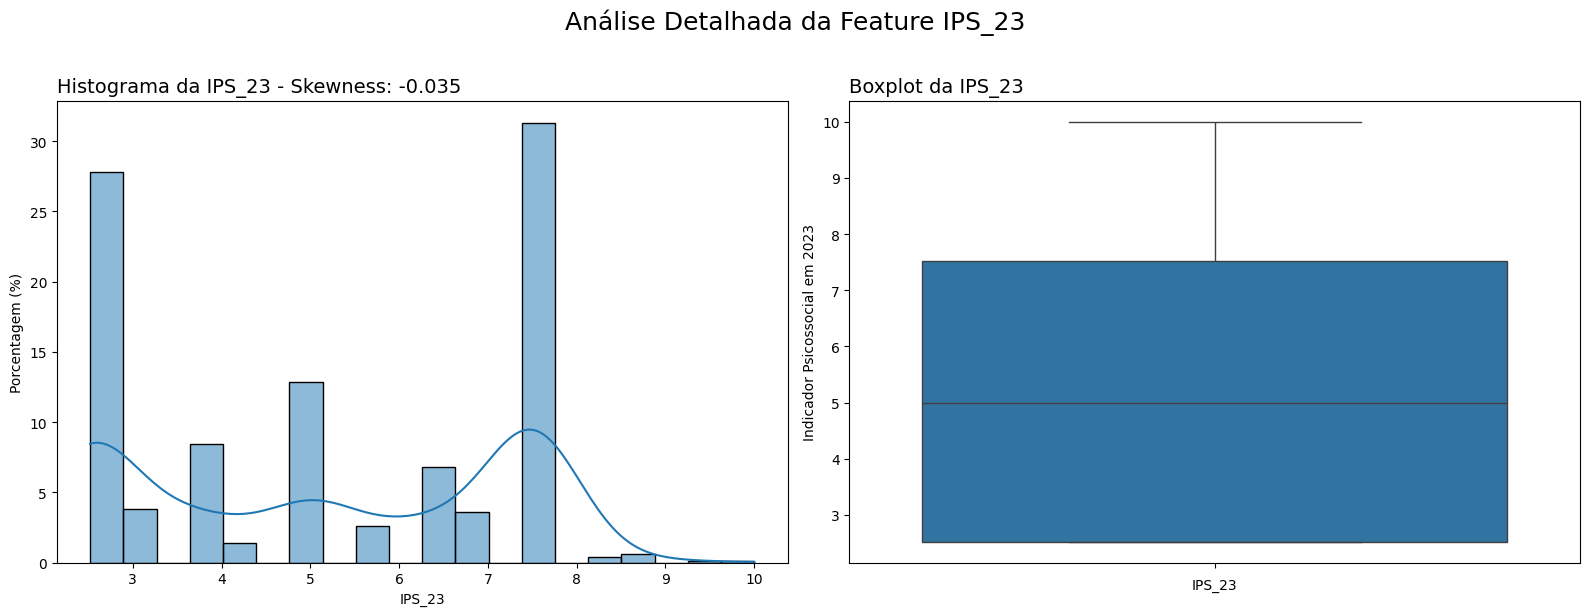

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IPS_23'].skew()

# Histograma
sns.histplot(df_loaded['IPS_23'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IPS_23 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IPS_23')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IPS_23'], ax=axes[1])
axes[1].set_title('Boxplot da IPS_23', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador Psicossocial em 2023')
axes[1].set_xlabel('IPS_23')

plt.suptitle('Análise Detalhada da Feature IPS_23', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IPS_23'], 'IPS_23')

--- Análise de Normalidade para a Feature: 'IPS_23' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.8355
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 5303.0040
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IDA_23

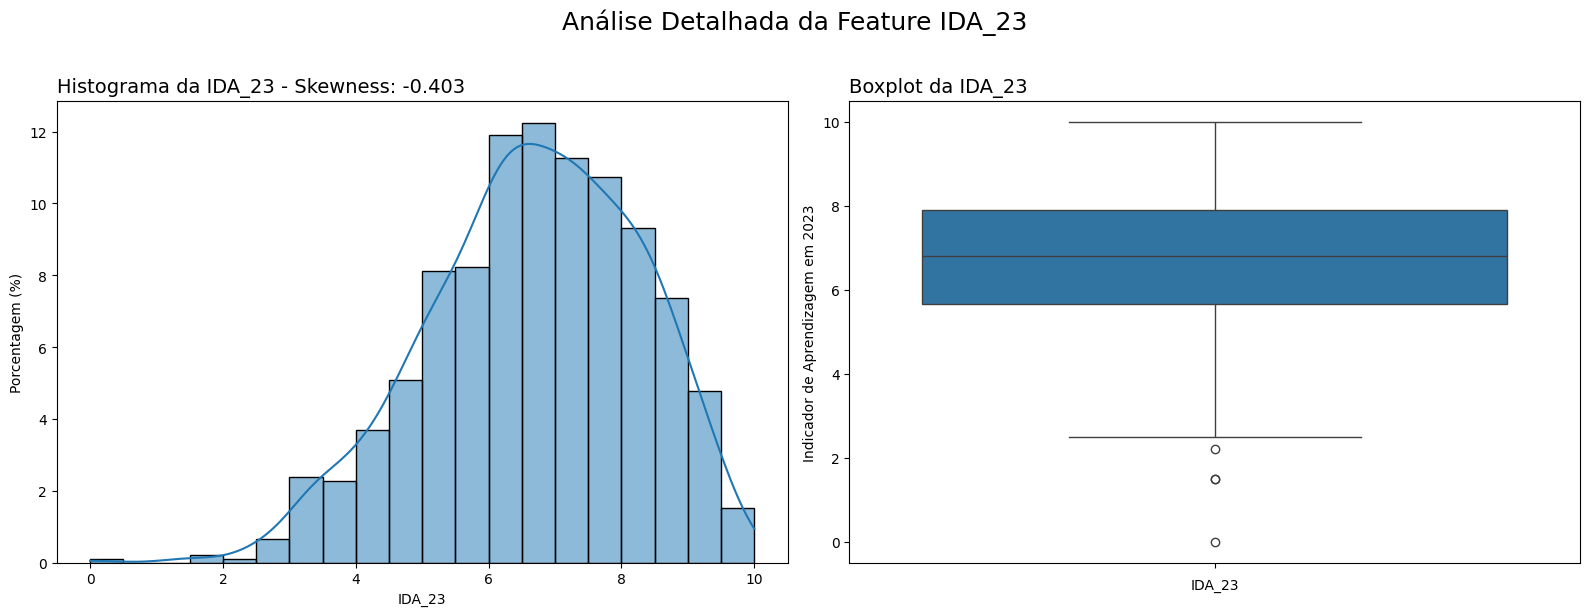

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IDA_23'].skew()

# Histograma
sns.histplot(df_loaded['IDA_23'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IDA_23 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IDA_23')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IDA_23'], ax=axes[1])
axes[1].set_title('Boxplot da IDA_23', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Aprendizagem em 2023')
axes[1].set_xlabel('IDA_23')

plt.suptitle('Análise Detalhada da Feature IDA_23', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IDA_23'], 'IDA_23')

--- Análise de Normalidade para a Feature: 'IDA_23' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.9851
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 23.8466
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IPV_23

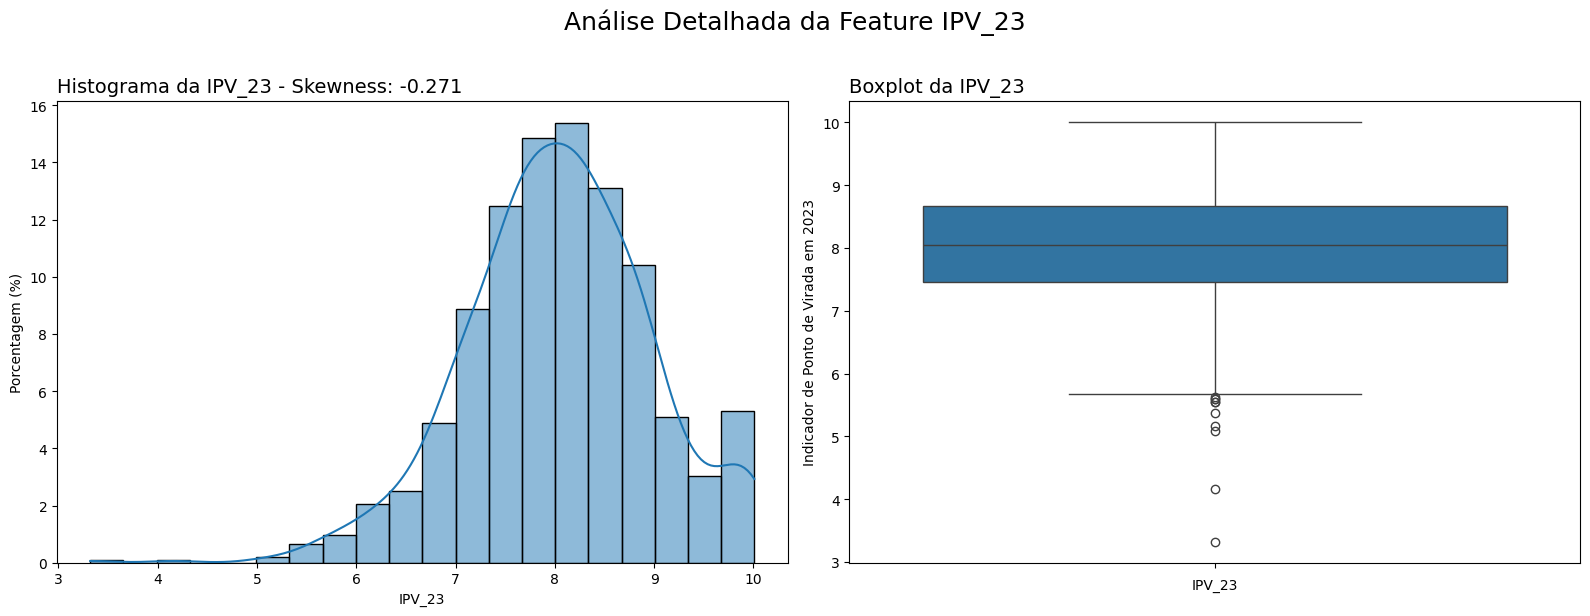

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IPV_23'].skew()

# Histograma
sns.histplot(df_loaded['IPV_23'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IPV_23 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IPV_23')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IPV_23'], ax=axes[1])
axes[1].set_title('Boxplot da IPV_23', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Ponto de Virada em 2023')
axes[1].set_xlabel('IPV_23')

plt.suptitle('Análise Detalhada da Feature IPV_23', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IPV_23'], 'IPV_23')

--- Análise de Normalidade para a Feature: 'IPV_23' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.9874
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 24.2428
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IAN_23

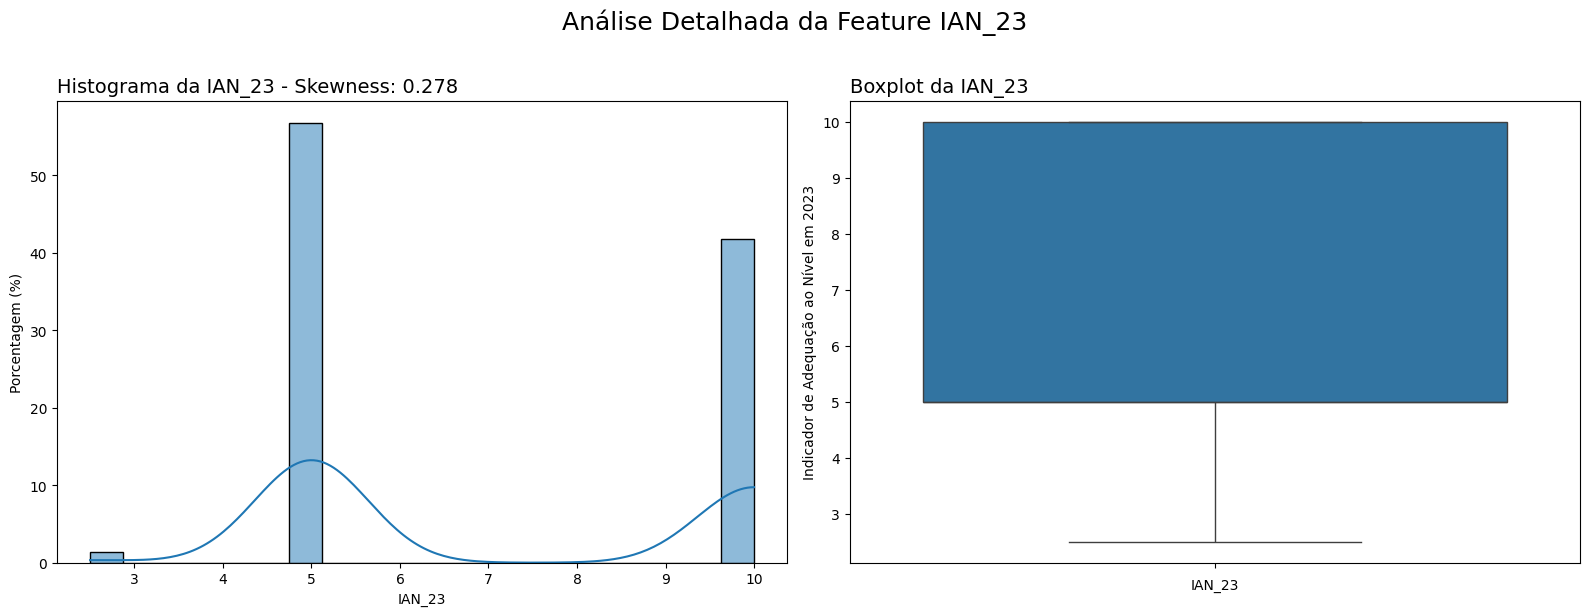

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IAN_23'].skew()

# Histograma
sns.histplot(df_loaded['IAN_23'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IAN_23 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IAN_23')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IAN_23'], ax=axes[1])
axes[1].set_title('Boxplot da IAN_23', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Adequação ao Nível em 2023')
axes[1].set_xlabel('IAN_23')

plt.suptitle('Análise Detalhada da Feature IAN_23', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IAN_23'], 'IAN_23')

--- Análise de Normalidade para a Feature: 'IAN_23' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.6603
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 4044.7940
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature VETERANO_23

In [38]:
order_by_label = df_loaded['VETERANO_23'].value_counts().index
class_counts = df_loaded['VETERANO_23'].value_counts()

class_percentages = (df_loaded['VETERANO_23'].value_counts(normalize=True, ) * 100).round(2)
print(class_percentages)

VETERANO_23
1.0    61.43
0.0    38.57
Name: proportion, dtype: float64


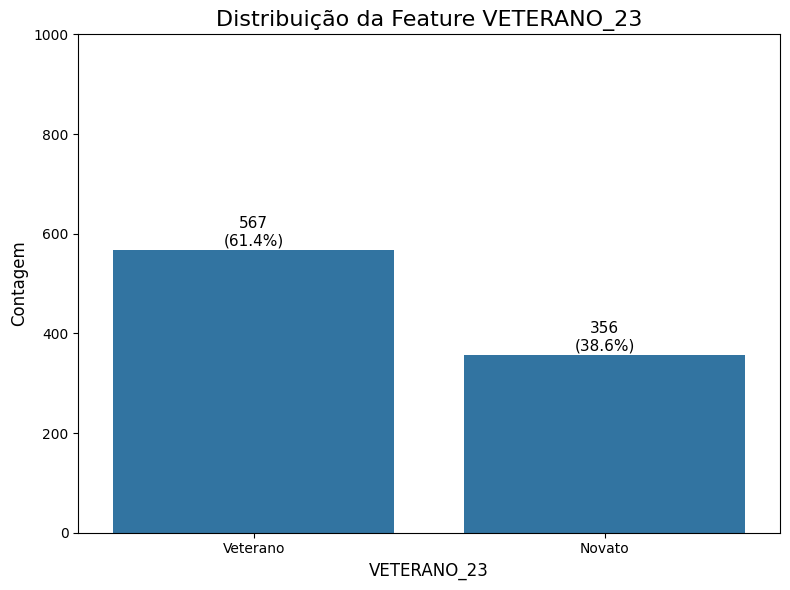

In [39]:
df = df_loaded['VETERANO_23'].copy()

# Mapear valores numéricos para labels
gender_map = {1: 'Veterano', 0: 'Novato'}
df_plot = pd.DataFrame(df).copy()
df_plot['VETERANO_LABEL'] = df_plot['VETERANO_23'].map(gender_map)

# Definir ordem (opcional - ajuste conforme necessário)
order_labels = ['Veterano', 'Novato']

# Visualização da distribuição da feature
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='VETERANO_LABEL', data=df_plot, order=order_labels)

plt.title('Distribuição da Feature VETERANO_23', fontsize=16)
plt.xlabel('VETERANO_23', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

# Adicionando rótulos
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Feature EM_FASE_23

In [40]:
order_by_label = df_loaded['EM_FASE_23'].value_counts().index
class_counts = df_loaded['EM_FASE_23'].value_counts()

class_percentages = (df_loaded['EM_FASE_23'].value_counts(normalize=True, ) * 100).round(2)
print(class_percentages)

EM_FASE_23
0.0    61.54
1.0    38.46
Name: proportion, dtype: float64


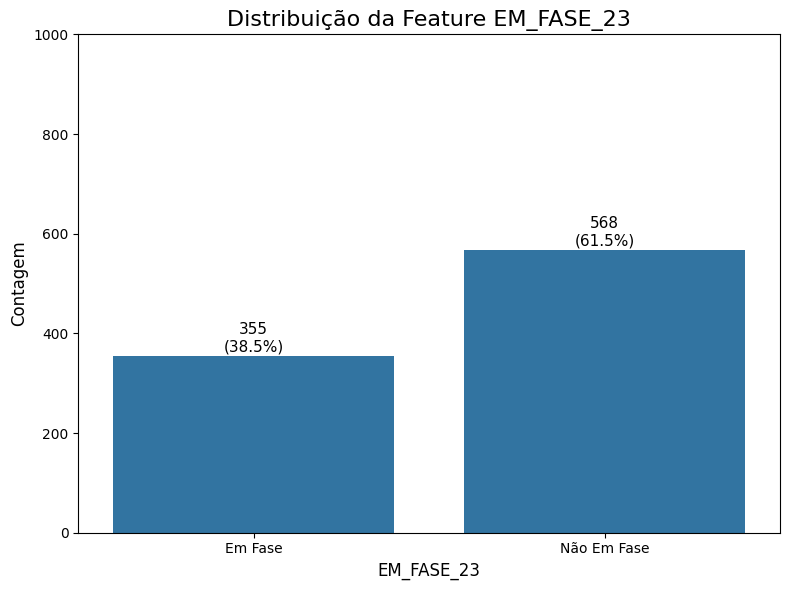

In [41]:
df = df_loaded['EM_FASE_23'].copy()

# Mapear valores numéricos para labels
gender_map = {1: 'Em Fase', 0: 'Não Em Fase'}
df_plot = pd.DataFrame(df).copy()
df_plot['EM_FASE_LABEL'] = df_plot['EM_FASE_23'].map(gender_map)

# Definir ordem (opcional - ajuste conforme necessário)
order_labels = ['Em Fase', 'Não Em Fase']

# Visualização da distribuição da feature
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='EM_FASE_LABEL', data=df_plot, order=order_labels)

plt.title('Distribuição da Feature EM_FASE_23', fontsize=16)
plt.xlabel('EM_FASE_23', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

# Adicionando rótulos
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Feature INSTITUICAO_ENSINO_23_mapped

In [42]:
order_by_label = df_loaded['INSTITUICAO_ENSINO_23_mapped'].value_counts().index
class_counts = df_loaded['INSTITUICAO_ENSINO_23_mapped'].value_counts()

class_percentages = (df_loaded['INSTITUICAO_ENSINO_23_mapped'].value_counts(normalize=True, ) * 100).round(2)
print(class_percentages)

INSTITUICAO_ENSINO_23_mapped
1    86.89
0    13.11
Name: proportion, dtype: float64


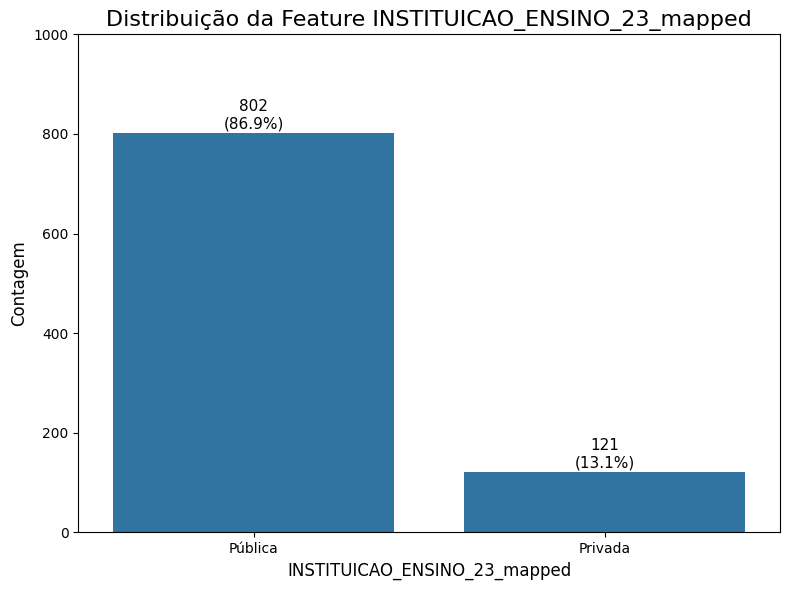

In [43]:
df = df_loaded['INSTITUICAO_ENSINO_23_mapped'].copy()

# Mapear valores numéricos para labels
gender_map = {1: 'Pública', 0: 'Privada'}
df_plot = pd.DataFrame(df).copy()
df_plot['INSTITUICAO_ENSINO_23_mapped_LABEL'] = df_plot['INSTITUICAO_ENSINO_23_mapped'].map(gender_map)

# Definir ordem (opcional - ajuste conforme necessário)
order_labels = ['Pública', 'Privada']

# Visualização da distribuição da feature
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='INSTITUICAO_ENSINO_23_mapped_LABEL', data=df_plot, order=order_labels)

plt.title('Distribuição da Feature INSTITUICAO_ENSINO_23_mapped', fontsize=16)
plt.xlabel('INSTITUICAO_ENSINO_23_mapped', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

# Adicionando rótulos
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Feature GÊNERO_23

In [44]:
order_by_label = df_loaded['GÊNERO_23'].value_counts().index
class_counts = df_loaded['GÊNERO_23'].value_counts()

class_percentages = (df_loaded['GÊNERO_23'].value_counts(normalize=True, ) * 100).round(2)
print(class_percentages)

GÊNERO_23
1.0    52.76
0.0    47.24
Name: proportion, dtype: float64


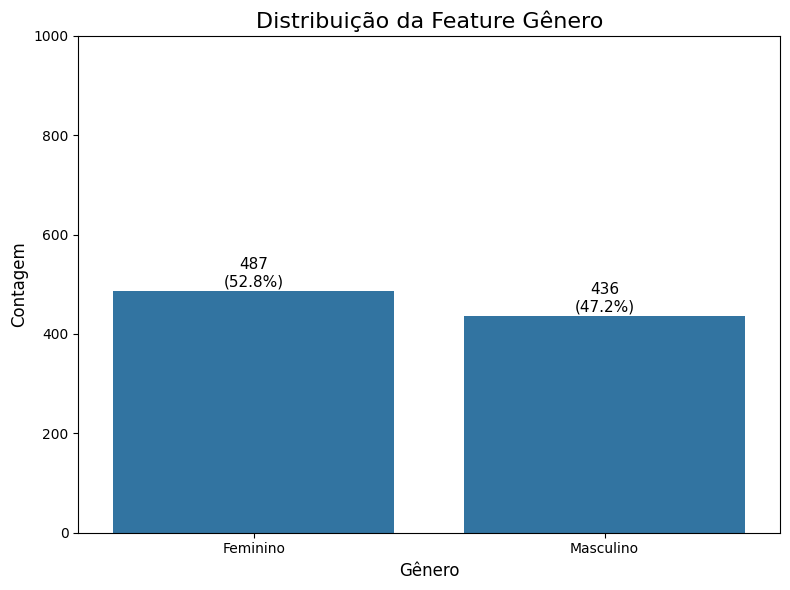

In [45]:
df = df_loaded['GÊNERO_23'].copy()

# Mapear valores numéricos para labels
gender_map = {1: 'Feminino', 0: 'Masculino'}
df_plot = pd.DataFrame(df).copy()
df_plot['GÊNERO_LABEL'] = df_plot['GÊNERO_23'].map(gender_map)

# Definir ordem (opcional - ajuste conforme necessário)
order_labels = ['Feminino', 'Masculino']

# Visualização da distribuição da feature
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='GÊNERO_LABEL', data=df_plot, order=order_labels)

plt.title('Distribuição da Feature Gênero', fontsize=16)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

# Adicionando rótulos
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Análise da variável resposta

In [46]:
order_by_label = df_loaded['EVADIU'].value_counts().index
class_counts = df_loaded['EVADIU'].value_counts()

class_percentages = df_loaded['EVADIU'].value_counts(normalize=True) * 100
print(class_percentages)

EVADIU
0.0    74.214518
1.0    25.785482
Name: proportion, dtype: float64


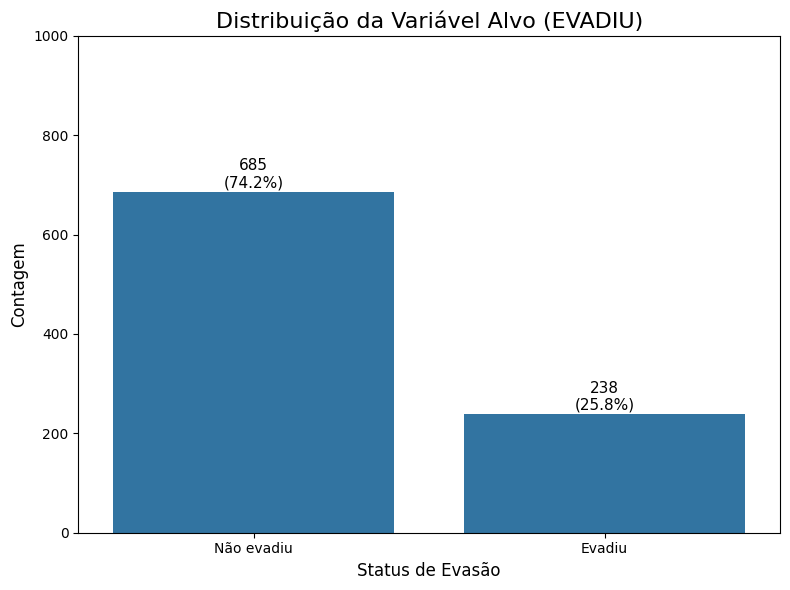

In [47]:
# Mapear os valores para labels primeiro
df_plot = df_loaded.copy()
df_plot['EVADIU_LABEL'] = df_plot['EVADIU'].map({0: 'Não evadiu', 1: 'Evadiu'})

# Visualização da distribuição da variável alvo
plt.figure(figsize=(8, 6))

order_labels = ['Não evadiu', 'Evadiu']
ax = sns.countplot(x='EVADIU_LABEL', data=df_plot, order=order_labels) 

plt.title('Distribuição da Variável Alvo (EVADIU)', fontsize=16)
plt.xlabel('Status de Evasão', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df_loaded)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

## Análise multivariada

### Matriz de correlação

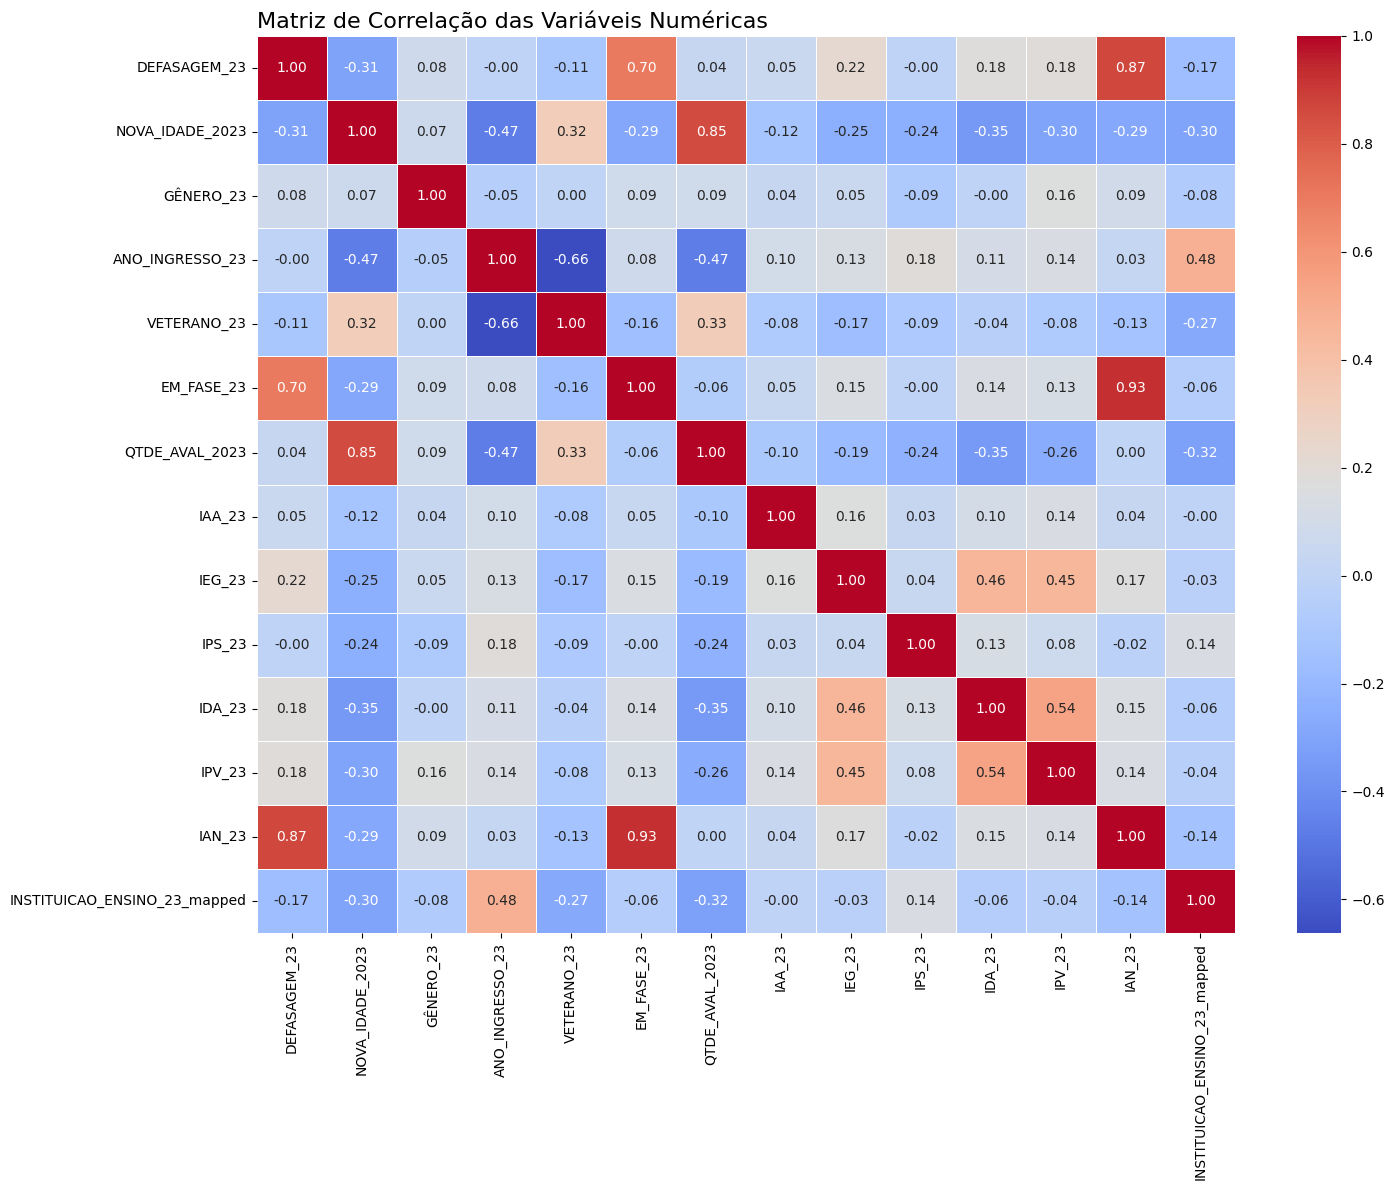

In [48]:
correlation_matrix = df_loaded[num_features].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Exibe os valores de correlação nas células
    cmap='coolwarm',     # Esquema de cores (azul para negativo, vermelho para positivo)
    fmt='.2f',           # Formata os números para duas casas decimais
    linewidths=.5        # Adiciona linhas finas entre as células
)

plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=16, loc='left')

plt.tight_layout()
plt.show()

### Análise das features por classe da variável alvo

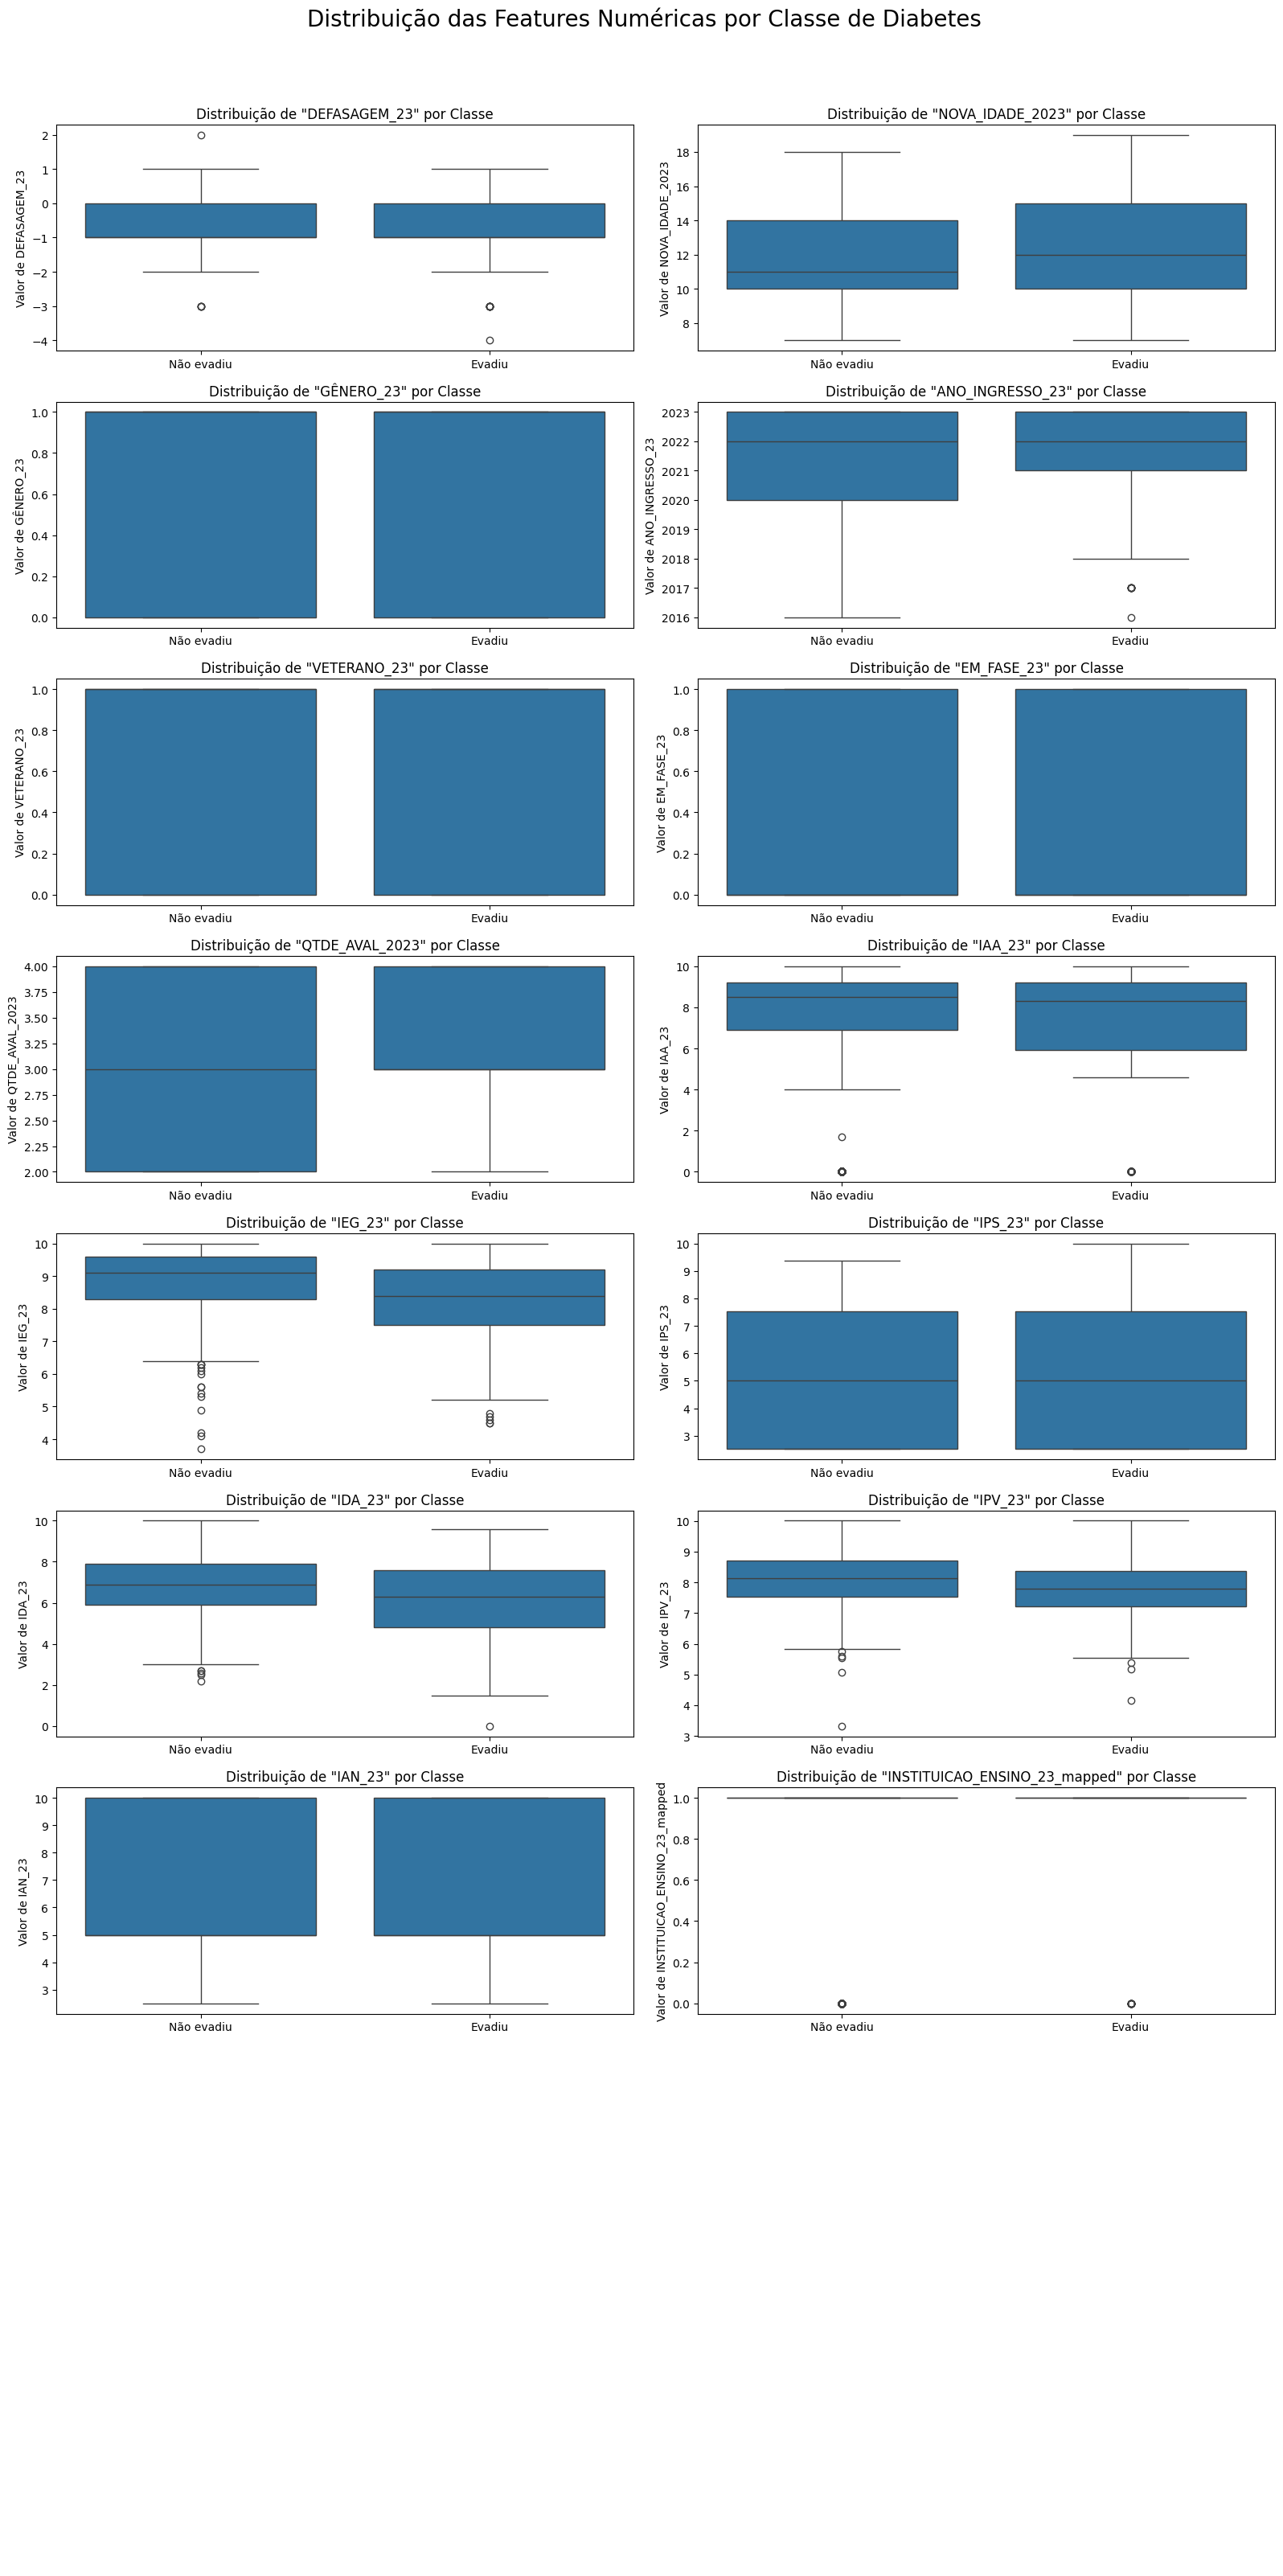

In [49]:
df_loaded['CLASS_LABEL'] = df_loaded['EVADIU'].map({0: 'Não evadiu', 1: 'Evadiu'})

class_order = df_loaded['CLASS_LABEL'].value_counts().index

nrows, ncols = 9, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 32))

# Achatar o array de eixos para facilitar a iteração
axes = axes.flatten()

# Iterando sobre as features e os eixos simultaneamente
for i, col in enumerate(num_features):
    ax = axes[i] # Seleciona o eixo atual
    sns.boxplot(
        x='CLASS_LABEL',
        y=col,
        data=df_loaded,
        order=class_order,
        ax=ax # Especifica em qual eixo o gráfico deve ser desenhado
    )
    ax.set_title(f'Distribuição de "{col}" por Classe', fontsize=12)
    ax.set_xlabel('') # Remove o rótulo do eixo X para limpar a visualização
    ax.set_ylabel(f'Valor de {col}', fontsize=10)
    ax.tick_params(axis='x', rotation=0)

# Ocultando os eixos extras que não foram utilizados
for i in range(len(num_features), len(axes)):
    axes[i].axis('off')

# Adicionando um título geral para toda a figura
fig.suptitle('Distribuição das Features Numéricas por Classe de Diabetes', fontsize=20, y=1.0)

# Ajustando o layout para evitar sobreposição
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### GÊNERO_23 x EVADIU

In [50]:
df_loaded['Gender_label'] = df_loaded['GÊNERO_23'].map({1: 'Feminino', 0: 'Masculino'})

# Criando a tabela de contingência
contingency_table = pd.crosstab(df_loaded['Gender_label'], df_loaded['CLASS_LABEL'])

print("Tabela de Contingência: Gender vs. Class\n")
print(contingency_table)

Tabela de Contingência: Gender vs. Class

CLASS_LABEL   Evadiu  Não evadiu
Gender_label                    
Feminino         125         362
Masculino        113         323



Tabela de Contingência (Percentual por Gênero):

CLASS_LABEL      Evadiu  Não evadiu
Gender_label                       
Feminino      25.667351   74.332649
Masculino     25.917431   74.082569


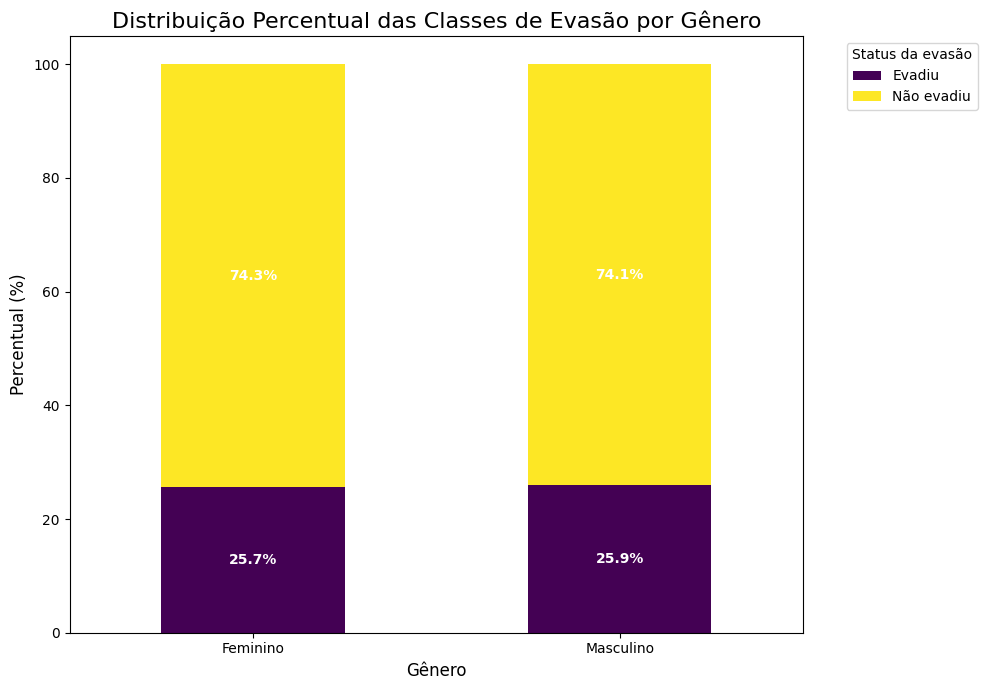

In [51]:
contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nTabela de Contingência (Percentual por Gênero):\n")
print(contingency_table_pct)

# Criando o gráfico de barras empilhadas 100%
ax = contingency_table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis'
)

plt.title('Distribuição Percentual das Classes de Evasão por Gênero', fontsize=16)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status da evasão', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem no gráfico
for c in ax.containers:
    # A formatação pode ser ajustada para melhor visualização
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [52]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Teste Qui-quadrado de Independência ---\n")
print(f"Estatística Qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Graus de Liberdade (dof): {dof}")

alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusão (alpha={alpha}): Rejeitamos a hipótese nula.")
    print("Há uma associação estatisticamente significativa entre Gênero e Classe de Evasão.")
else:
    print(f"\nConclusão (alpha={alpha}): Falhamos em rejeitar a hipótese nula.")
    print("Não há evidência de uma associação estatisticamente significativa entre Gênero e Classe de Evasão.")


--- Teste Qui-quadrado de Independência ---

Estatística Qui-quadrado: 0.0001
P-valor: 0.9909
Graus de Liberdade (dof): 1

Conclusão (alpha=0.05): Falhamos em rejeitar a hipótese nula.
Não há evidência de uma associação estatisticamente significativa entre Gênero e Classe de Evasão.


### VETERANO_23 x EVADIU

In [53]:
df_loaded['Veterano_label'] = df_loaded['VETERANO_23'].map({1: 'Veterano', 0: 'Novato'})

# Criando a tabela de contingência
contingency_table = pd.crosstab(df_loaded['Veterano_label'], df_loaded['CLASS_LABEL'])

print("Tabela de Contingência: Veterano vs. Class\n")
print(contingency_table)

Tabela de Contingência: Veterano vs. Class

CLASS_LABEL     Evadiu  Não evadiu
Veterano_label                    
Novato             113         243
Veterano           125         442



Tabela de Contingência (Percentual por Veterano):

CLASS_LABEL        Evadiu  Não evadiu
Veterano_label                       
Novato          31.741573   68.258427
Veterano        22.045855   77.954145


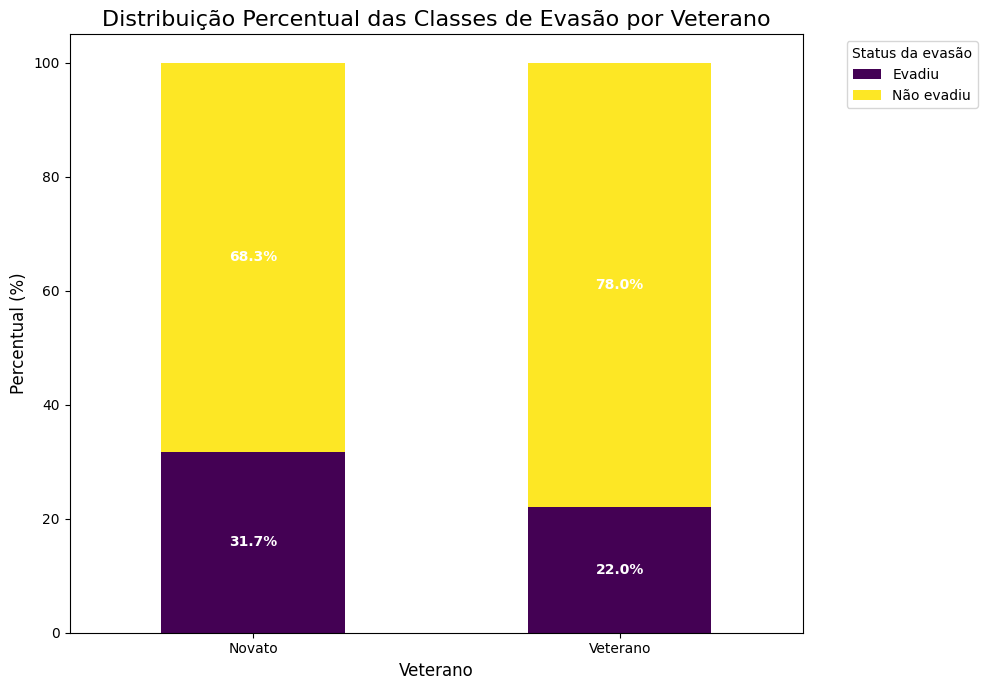

In [54]:
contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nTabela de Contingência (Percentual por Veterano):\n")
print(contingency_table_pct)

# Criando o gráfico de barras empilhadas 100%
ax = contingency_table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis'
)

plt.title('Distribuição Percentual das Classes de Evasão por Veterano', fontsize=16)
plt.xlabel('Veterano', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status da evasão', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem no gráfico
for c in ax.containers:
    # A formatação pode ser ajustada para melhor visualização
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [55]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Teste Qui-quadrado de Independência ---\n")
print(f"Estatística Qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Graus de Liberdade (dof): {dof}")

alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusão (alpha={alpha}): Rejeitamos a hipótese nula.")
    print("Há uma associação estatisticamente significativa entre Veterano e Classe de Evasão.")
else:
    print(f"\nConclusão (alpha={alpha}): Falhamos em rejeitar a hipótese nula.")
    print("Não há evidência de uma associação estatisticamente significativa entre Veterano e Classe de Evasão.")


--- Teste Qui-quadrado de Independência ---

Estatística Qui-quadrado: 10.2424
P-valor: 0.0014
Graus de Liberdade (dof): 1

Conclusão (alpha=0.05): Rejeitamos a hipótese nula.
Há uma associação estatisticamente significativa entre Veterano e Classe de Evasão.


### EM_FASE_23 x EVADIU

In [56]:
df_loaded['Defasagem_label'] = df_loaded['EM_FASE_23'].map({1: 'Em fase', 0: 'Defasado'})

# Criando a tabela de contingência
contingency_table = pd.crosstab(df_loaded['Defasagem_label'], df_loaded['CLASS_LABEL'])

print("Tabela de Contingência: Defasagem vs. Class\n")
print(contingency_table)

Tabela de Contingência: Defasagem vs. Class

CLASS_LABEL      Evadiu  Não evadiu
Defasagem_label                    
Defasado            158         410
Em fase              80         275



Tabela de Contingência (Percentual por Defasagem):

CLASS_LABEL         Evadiu  Não evadiu
Defasagem_label                       
Defasado         27.816901   72.183099
Em fase          22.535211   77.464789


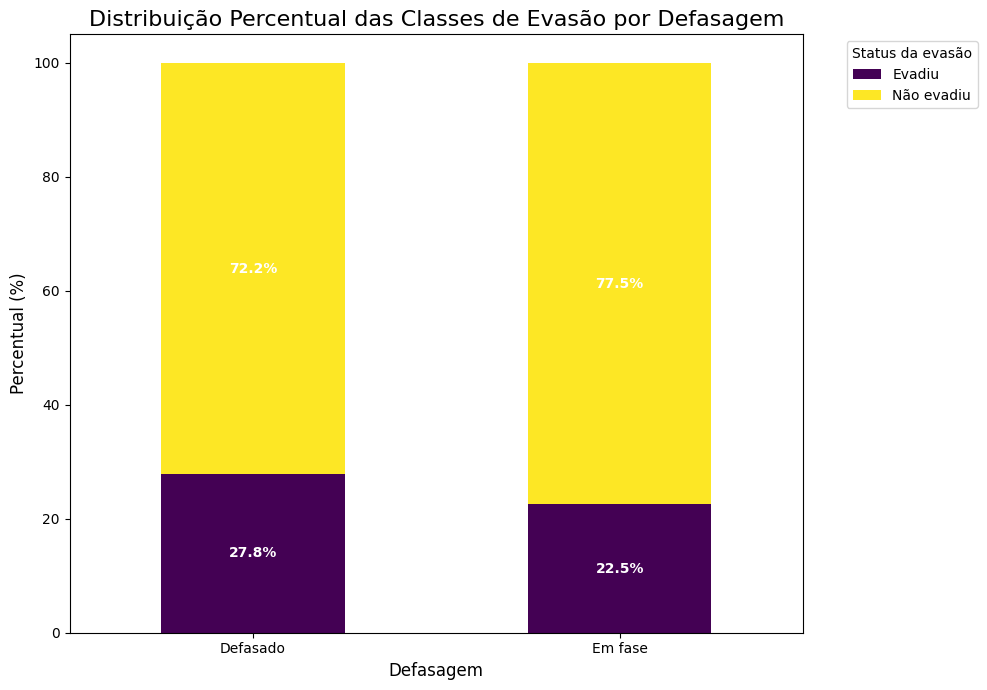

In [57]:
contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nTabela de Contingência (Percentual por Defasagem):\n")
print(contingency_table_pct)

# Criando o gráfico de barras empilhadas 100%
ax = contingency_table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis'
)

plt.title('Distribuição Percentual das Classes de Evasão por Defasagem', fontsize=16)
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status da evasão', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem no gráfico
for c in ax.containers:
    # A formatação pode ser ajustada para melhor visualização
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [58]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Teste Qui-quadrado de Independência ---\n")
print(f"Estatística Qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Graus de Liberdade (dof): {dof}")

alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusão (alpha={alpha}): Rejeitamos a hipótese nula.")
    print("Há uma associação estatisticamente significativa entre Defasagem e Classe de Evasão.")
else:
    print(f"\nConclusão (alpha={alpha}): Falhamos em rejeitar a hipótese nula.")
    print("Não há evidência de uma associação estatisticamente significativa entre Defasagem e Classe de Evasão.")


--- Teste Qui-quadrado de Independência ---

Estatística Qui-quadrado: 2.9146
P-valor: 0.0878
Graus de Liberdade (dof): 1

Conclusão (alpha=0.05): Falhamos em rejeitar a hipótese nula.
Não há evidência de uma associação estatisticamente significativa entre Defasagem e Classe de Evasão.


### INSTITUICAO_ENSINO_23 x EVADIU

In [59]:
df_loaded['Instituicao_label'] = df_loaded['INSTITUICAO_ENSINO_23_mapped'].map({1: 'Pública', 0: 'Privada'})

# Criando a tabela de contingência
contingency_table = pd.crosstab(df_loaded['Instituicao_label'], df_loaded['CLASS_LABEL'])

print("Tabela de Contingência: Instituição vs. Class\n")
print(contingency_table)

Tabela de Contingência: Instituição vs. Class

CLASS_LABEL        Evadiu  Não evadiu
Instituicao_label                    
Privada                16         105
Pública               222         580



Tabela de Contingência (Percentual por Instituição):

CLASS_LABEL           Evadiu  Não evadiu
Instituicao_label                       
Privada            13.223140   86.776860
Pública            27.680798   72.319202


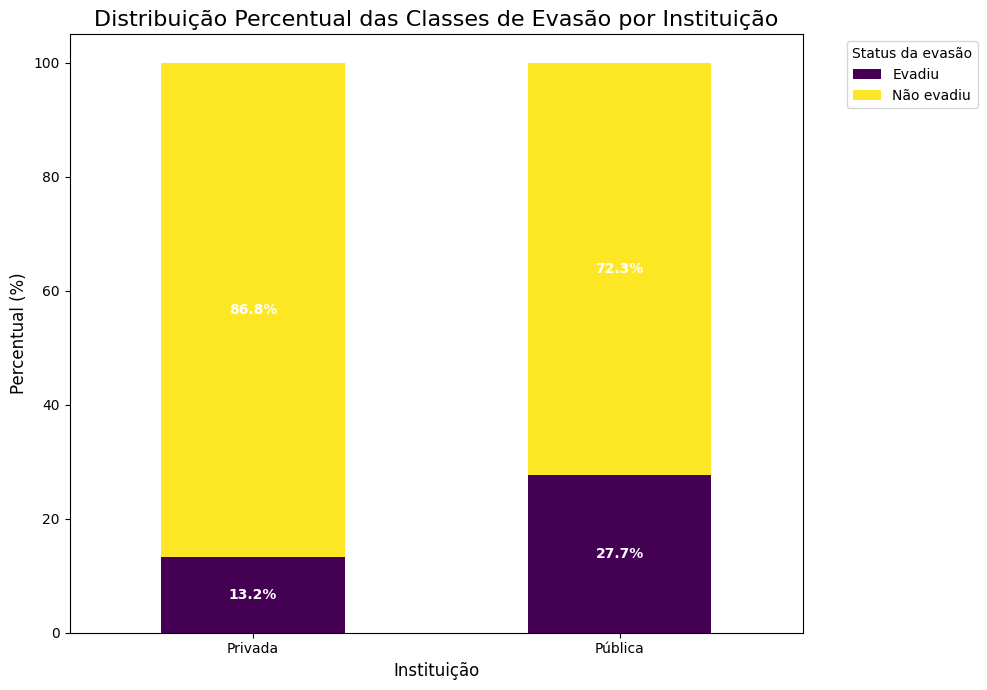

In [60]:
contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nTabela de Contingência (Percentual por Instituição):\n")
print(contingency_table_pct)

# Criando o gráfico de barras empilhadas 100%
ax = contingency_table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis'
)

plt.title('Distribuição Percentual das Classes de Evasão por Instituição', fontsize=16)
plt.xlabel('Instituição', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status da evasão', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem no gráfico
for c in ax.containers:
    # A formatação pode ser ajustada para melhor visualização
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [61]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Teste Qui-quadrado de Independência ---\n")
print(f"Estatística Qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Graus de Liberdade (dof): {dof}")

alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusão (alpha={alpha}): Rejeitamos a hipótese nula.")
    print("Há uma associação estatisticamente significativa entre Instituição e Classe de Evasão.")
else:
    print(f"\nConclusão (alpha={alpha}): Falhamos em rejeitar a hipótese nula.")
    print("Não há evidência de uma associação estatisticamente significativa entre Instituição e Classe de Evasão.")


--- Teste Qui-quadrado de Independência ---

Estatística Qui-quadrado: 10.7408
P-valor: 0.0010
Graus de Liberdade (dof): 1

Conclusão (alpha=0.05): Rejeitamos a hipótese nula.
Há uma associação estatisticamente significativa entre Instituição e Classe de Evasão.


### PairPlot

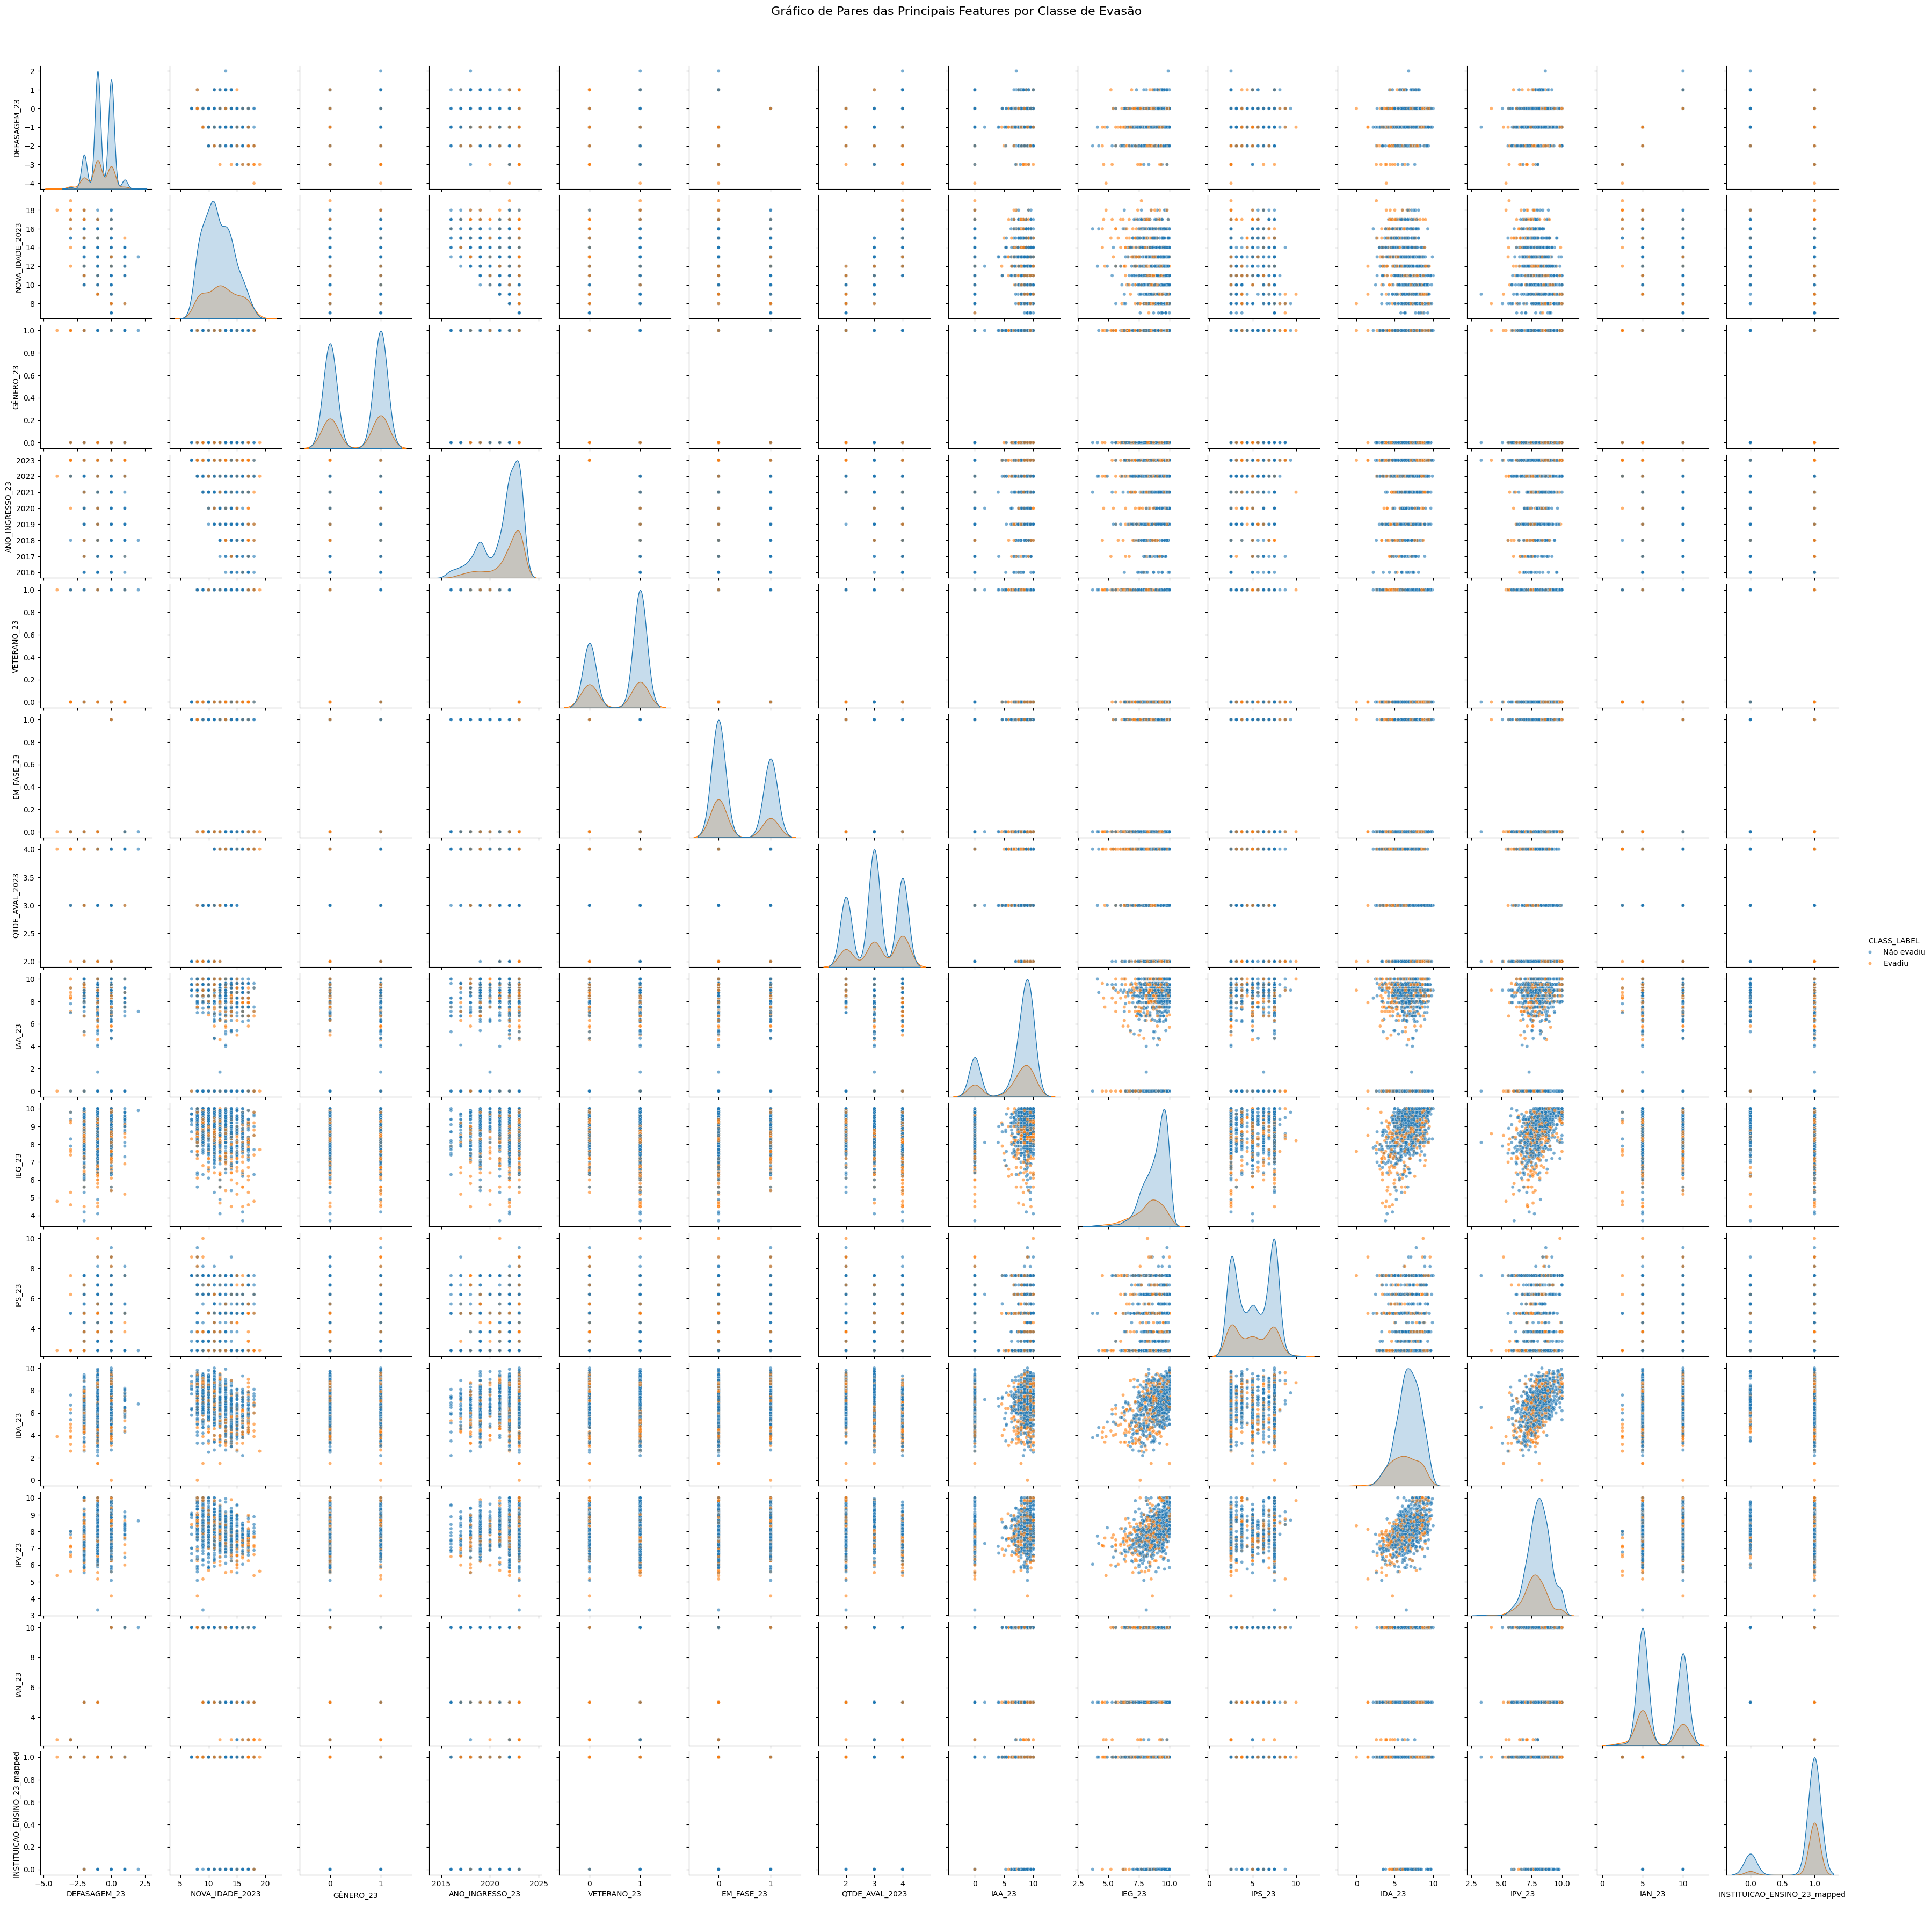

In [62]:
features_for_pairplot = num_features

# Criando o pair plot
# diag_kind='kde' mostra a densidade da distribuição na diagonal
g = sns.pairplot(
    data=df_loaded,
    vars=features_for_pairplot,
    hue='CLASS_LABEL',
    #palette='viridis', # Esquema de cores
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 20} # Ajusta a transparência e o tamanho dos pontos
)

# Adicionando um título geral
g.fig.suptitle('Gráfico de Pares das Principais Features por Classe de Evasão', y=1.02, fontsize=16)

plt.show()

# Pré-processamento

## Transformação logarítmica

In [63]:
skewness = df_loaded[num_features].drop(columns=['INSTITUICAO_ENSINO_23_mapped']).skew()

# Selecionando colunas com skewness >= 1 ou <= -1
high_skew_columns = skewness[(skewness >= 1) | (skewness <= -1)]

# Nomes das colunas com alta skewness
skew_column_names = high_skew_columns.index.tolist()

df_log = aplicar_transformacao_log(df_loaded, skew_column_names)

display(df_log[[col for col in df_log.columns.tolist() if col.endswith("_log")]].head())

,ANO_INGRESSO_23_log,IAA_23_log,IEG_23_log
0,7.612831,2.251292,2.341806
1,7.612831,2.302585,2.312535
2,7.612831,2.302585,2.370244
3,7.612831,2.302585,2.251292
4,7.612831,2.302585,2.360854


### Visualização da transformação

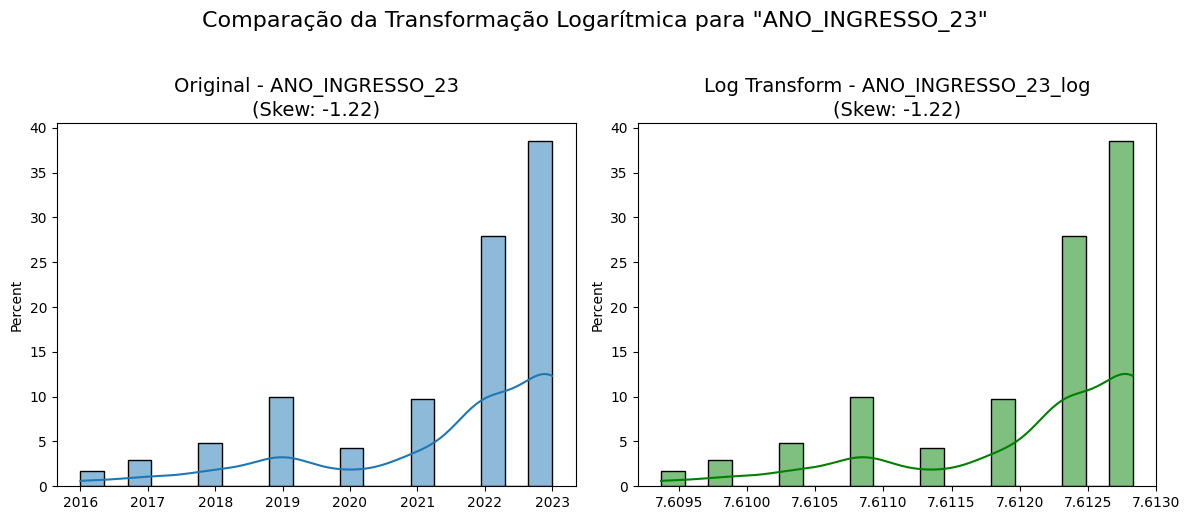

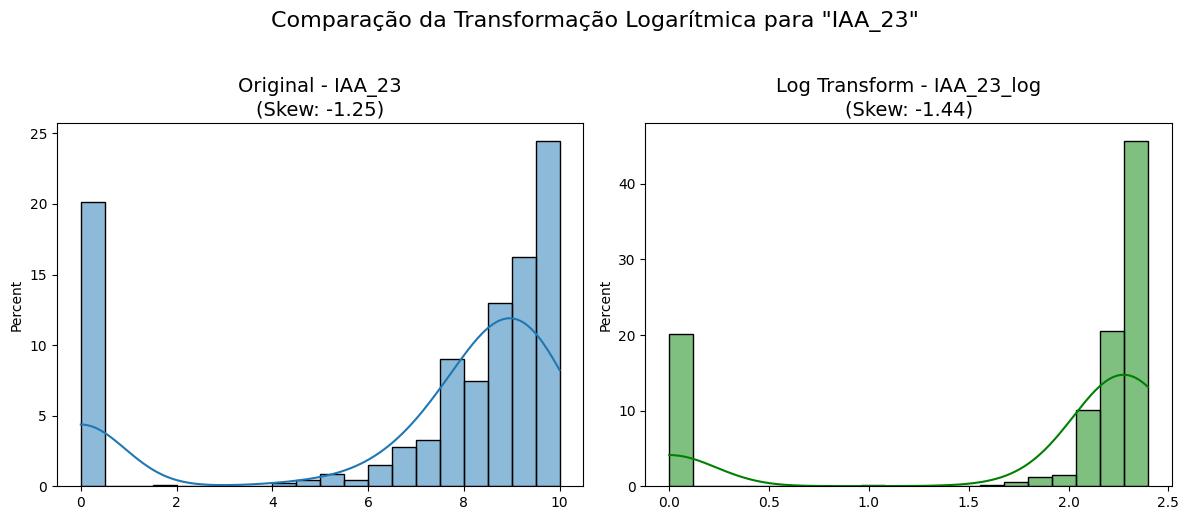

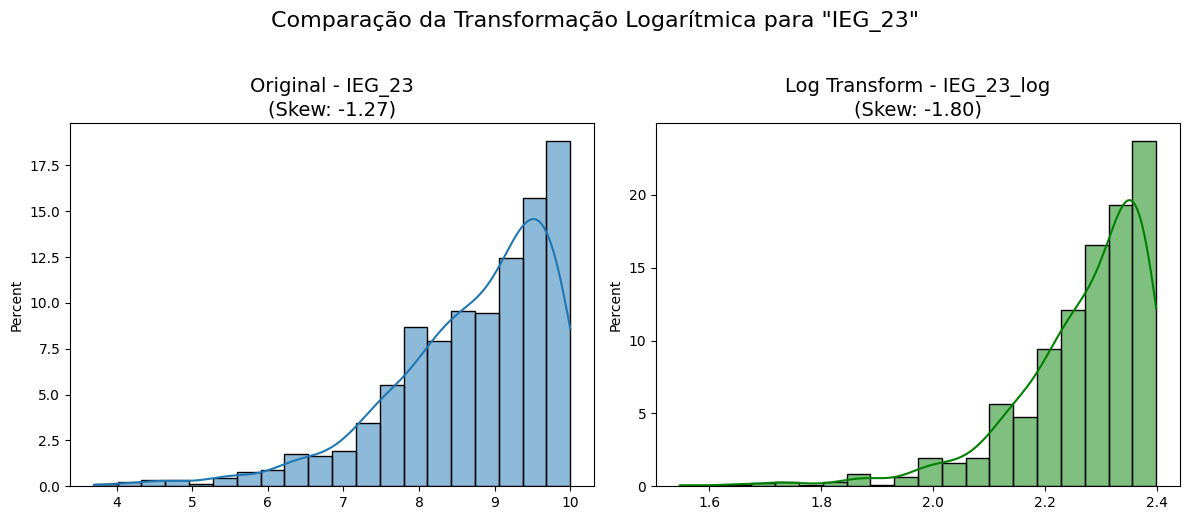

In [64]:
for col in skew_column_names:
    # Criando a figura e os eixos para o subplot (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Gráfico 1: Distribuição Original ---
    skew_original = df_log[col].skew()
    sns.histplot(df_log[col], kde=True, ax=axes[0], bins=20, stat='percent')
    axes[0].set_title(f'Original - {col}\n(Skew: {skew_original:.2f})', fontsize=14)
    axes[0].set_xlabel('')

    # --- Gráfico 2: Distribuição com Transformação Logarítmica ---
    col_log = col + '_log'
    skew_transformado = df_log[col_log].skew()
    sns.histplot(df_log[col_log], kde=True, ax=axes[1], bins=20, stat='percent', color='green')
    axes[1].set_title(f'Log Transform - {col_log}\n(Skew: {skew_transformado:.2f})', fontsize=14)
    axes[1].set_xlabel('')

    # Título geral
    fig.suptitle(f'Comparação da Transformação Logarítmica para "{col}"', fontsize=16, y=1.03)

    plt.tight_layout()
    plt.show()

In [65]:
df_loaded[num_features]

,DEFASAGEM_23,NOVA_IDADE_2023,GÊNERO_23,ANO_INGRESSO_23,VETERANO_23,EM_FASE_23,QTDE_AVAL_2023,IAA_23,IEG_23,IPS_23,IDA_23,IPV_23,IAN_23,INSTITUICAO_ENSINO_23_mapped
0,0.0,8.0,1.0,2023.0,0.0,1.0,2.0,8.5,9.4,3.77,7.0,8.920,10.0,1
1,-1.0,9.0,1.0,2023.0,0.0,0.0,2.0,9.0,9.1,7.52,7.8,9.170,5.0,1
2,-1.0,9.0,1.0,2023.0,0.0,0.0,2.0,9.0,9.7,7.52,7.0,8.920,5.0,1
3,0.0,8.0,0.0,2023.0,0.0,1.0,2.0,9.0,8.5,7.52,4.0,8.750,10.0,1
4,0.0,9.0,1.0,2023.0,0.0,1.0,2.0,9.0,9.6,7.52,7.9,7.420,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,-2.0,11.0,1.0,2023.0,0.0,0.0,2.0,9.5,7.9,3.77,5.1,7.180,5.0,1
919,-1.0,9.0,0.0,2023.0,0.0,0.0,2.0,10.0,9.2,3.77,8.6,10.010,5.0,1
920,0.0,8.0,0.0,2023.0,0.0,1.0,2.0,7.5,8.7,3.77,7.1,8.595,10.0,1
921,-2.0,11.0,1.0,2023.0,0.0,0.0,2.0,9.5,9.3,3.77,7.9,9.840,5.0,1


## Separação dos dados para modelagem

### selecionando as colunas alvo

In [66]:
df_loaded[num_features].head()

,DEFASAGEM_23,NOVA_IDADE_2023,GÊNERO_23,ANO_INGRESSO_23,VETERANO_23,EM_FASE_23,QTDE_AVAL_2023,IAA_23,IEG_23,IPS_23,IDA_23,IPV_23,IAN_23,INSTITUICAO_ENSINO_23_mapped
0,0.0,8.0,1.0,2023.0,0.0,1.0,2.0,8.5,9.4,3.77,7.0,8.92,10.0,1
1,-1.0,9.0,1.0,2023.0,0.0,0.0,2.0,9.0,9.1,7.52,7.8,9.17,5.0,1
2,-1.0,9.0,1.0,2023.0,0.0,0.0,2.0,9.0,9.7,7.52,7.0,8.92,5.0,1
3,0.0,8.0,0.0,2023.0,0.0,1.0,2.0,9.0,8.5,7.52,4.0,8.75,10.0,1
4,0.0,9.0,1.0,2023.0,0.0,1.0,2.0,9.0,9.6,7.52,7.9,7.42,10.0,1


In [67]:
analise_nulos(df_loaded)

,nome_coluna,qtd_nulos,porcentagem_nulos
0,RA,0,0.0
1,FASE_23,0,0.0
2,NOVA_TURMA_23,0,0.0
3,DEFASAGEM_23,0,0.0
4,NOVA_FASE_IDEAL_23,0,0.0
5,NOVA_IDADE_2023,0,0.0
6,GÊNERO_23,0,0.0
7,ANO_INGRESSO_23,0,0.0
8,INSTITUICAO_ENSINO_23,0,0.0
9,VETERANO_23,0,0.0


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    df_loaded[num_features],
    df_loaded['EVADIU'],
    test_size=0.2,
    random_state=42,
    stratify=df_loaded['EVADIU']
)

# Modelagem - Random Forest

## Parâmetros e modelo

In [69]:
N_SPLITS = 5 # Número de folds para a validação cruzada
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [70]:
rf_params = {
    'n_estimators': 200,
    'criterion': 'log_loss',
    'max_depth': 5,
    'max_features': X_train.shape[1],
    'class_weight': 'balanced',
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

model_rf = RandomForestClassifier(**rf_params)

## Validação cruzada

In [71]:
results_rf = perform_cross_validation(
    X_train=X_train,
    y_train=y_train,
    skf=skf,
    model=model_rf,
)


Processando Fold 1/5

Train      - Acc: 0.8441 | F1: 0.7125 | ROC-AUC: 0.9031
Validation - Acc: 0.6351 | F1: 0.3721 | ROC-AUC: 0.6567

Processando Fold 2/5

Train      - Acc: 0.8407 | F1: 0.7081 | ROC-AUC: 0.9009
Validation - Acc: 0.6824 | F1: 0.2540 | ROC-AUC: 0.6577

Processando Fold 3/5

Train      - Acc: 0.8017 | F1: 0.6686 | ROC-AUC: 0.8907
Validation - Acc: 0.6757 | F1: 0.4667 | ROC-AUC: 0.6675

Processando Fold 4/5

Train      - Acc: 0.8257 | F1: 0.6888 | ROC-AUC: 0.8978
Validation - Acc: 0.7075 | F1: 0.4557 | ROC-AUC: 0.7400

Processando Fold 5/5

Train      - Acc: 0.8393 | F1: 0.7198 | ROC-AUC: 0.9145
Validation - Acc: 0.6735 | F1: 0.3684 | ROC-AUC: 0.6420

✅ Validação Cruzada concluída!


In [72]:
print("\n--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---")

for metric_name in results_rf['validation']:
    mean_train = np.mean(results_rf['train'][metric_name])
    std_train = np.std(results_rf['train'][metric_name])
    mean_val = np.mean(results_rf['validation'][metric_name])
    std_val = np.std(results_rf['validation'][metric_name])

    print(f"\nMétrica: {metric_name.replace('_', ' ').title()}")
    print(f"  - Treino     : {mean_train:.4f} ± {std_train:.4f}")
    print(f"  - Validação  : {mean_val:.4f} ± {std_val:.4f}")


--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---

Métrica: Accuracy
  - Treino     : 0.8303 ± 0.0156
  - Validação  : 0.6748 ± 0.0232

Métrica: F1 Score
  - Treino     : 0.6995 ± 0.0186
  - Validação  : 0.3834 ± 0.0765

Métrica: Recall
  - Treino     : 0.7658 ± 0.0211
  - Validação  : 0.4053 ± 0.1148

Métrica: Precision
  - Treino     : 0.6451 ± 0.0324
  - Validação  : 0.3729 ± 0.0441

Métrica: Log Loss
  - Treino     : 0.4781 ± 0.0081
  - Validação  : 0.5950 ± 0.0156

Métrica: Roc Auc
  - Treino     : 0.9014 ± 0.0078
  - Validação  : 0.6728 ± 0.0346

Métrica: Pr Auc
  - Treino     : 0.7875 ± 0.0134
  - Validação  : 0.4123 ± 0.0561


## Testando modelo

In [73]:
feature_names = X_train.columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

In [74]:
model_rf = RandomForestClassifier(**rf_params)

print("Treinando o modelo final com os dados de treino completos...")
model_rf.fit(X_train_scaled, y_train) # esse modelo tá pronto pra uso!

print("Avaliando o modelo no conjunto de teste...")
y_pred = model_rf.predict(X_test_scaled)
y_proba = model_rf.predict_proba(X_test_scaled)

Treinando o modelo final com os dados de treino completos...
Avaliando o modelo no conjunto de teste...


## Métricas e visualizações

In [75]:
# Extrair probabilidade da classe positiva (coluna 1)
y_proba_pos = y_proba[:, 1]

# Calcular métricas para classificação binária
test_metrics_rf = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, pos_label=1),  # Binário: pos_label=1
    'recall': recall_score(y_test, y_pred, pos_label=1),  # Sensibilidade
    'precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
    'log_loss': log_loss(y_test, y_proba),  # Sem multiplicar por -1
    'roc_auc': roc_auc_score(y_test, y_proba_pos),  # Usa apenas prob da classe positiva
}

print("\n📊 MÉTRICAS NO CONJUNTO DE TESTE:")
print("="*50)
for name, value in test_metrics_rf.items():
    print(f"  {name.replace('_', ' ').title():15s}: {value:.4f}")


📊 MÉTRICAS NO CONJUNTO DE TESTE:
  Accuracy       : 0.6270
  F1 Score       : 0.4298
  Recall         : 0.5417
  Precision      : 0.3562
  Log Loss       : 0.5783
  Roc Auc        : 0.7302


### Scatter plot do logloss

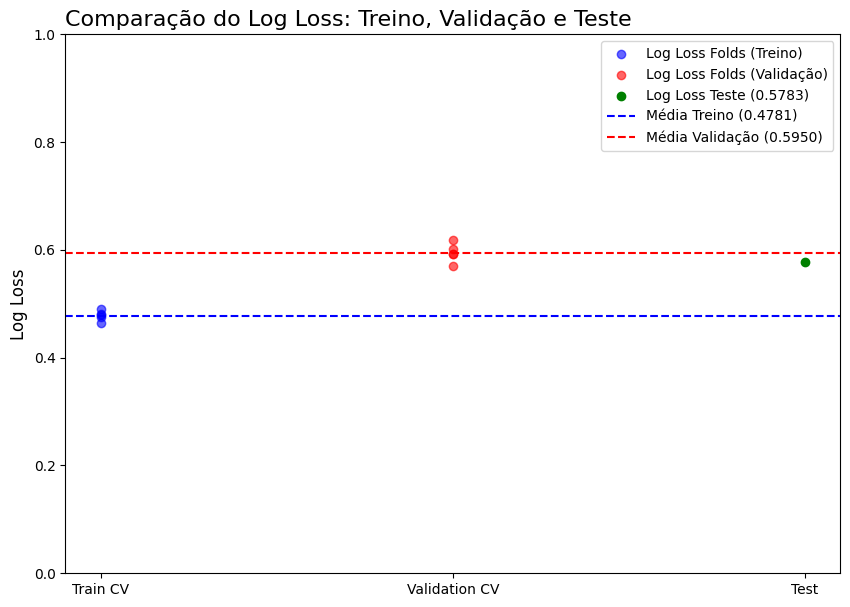

In [76]:
plt.figure(figsize=(10, 7))

labels = ['Train CV', 'Validation CV', 'Test']
train_losses = results_rf['train']['log_loss']
val_losses = results_rf['validation']['log_loss']
test_loss = test_metrics_rf['log_loss']

plt.scatter(y=train_losses, x=['Train CV']*N_SPLITS, color='blue', alpha=0.6, label='Log Loss Folds (Treino)')
plt.scatter(y=val_losses, x=['Validation CV']*N_SPLITS, color='red', alpha=0.6, label='Log Loss Folds (Validação)')
plt.scatter([2], [test_loss], color='green', label=f'Log Loss Teste ({test_loss:.4f})')

mean_train_loss = np.mean(train_losses)
mean_val_loss = np.mean(val_losses)

plt.axhline(y=mean_train_loss, color='blue', linestyle='--', label=f'Média Treino ({mean_train_loss:.4f})')
plt.axhline(y=mean_val_loss, color='red', linestyle='--', label=f'Média Validação ({mean_val_loss:.4f})')

plt.title('Comparação do Log Loss: Treino, Validação e Teste', fontsize=16, loc='left')
plt.ylabel('Log Loss', fontsize=12)

plt.xticks(range(len(labels)), labels)
plt.ylim(0, 1)
plt.legend()
plt.grid(False)
plt.show()

### Matriz de confusão

In [77]:
list(order_by_label)
order_by_label = ['Não evadiu', 'Evadiu']

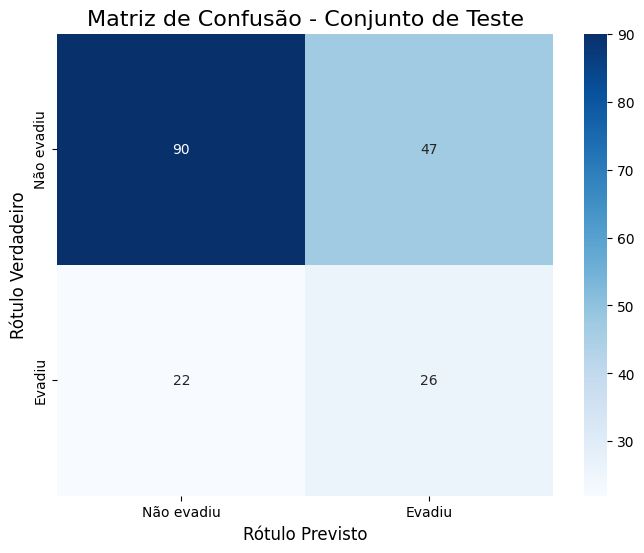

In [78]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(order_by_label), yticklabels=list(order_by_label))
plt.title('Matriz de Confusão - Conjunto de Teste', fontsize=16)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.show()

In [79]:
print(classification_report(y_test, y_pred, target_names=[str(c) for c in list(order_by_label)], digits=4))

              precision    recall  f1-score   support

  Não evadiu     0.8036    0.6569    0.7229       137
      Evadiu     0.3562    0.5417    0.4298        48

    accuracy                         0.6270       185
   macro avg     0.5799    0.5993    0.5763       185
weighted avg     0.6875    0.6270    0.6468       185



### Feature importance

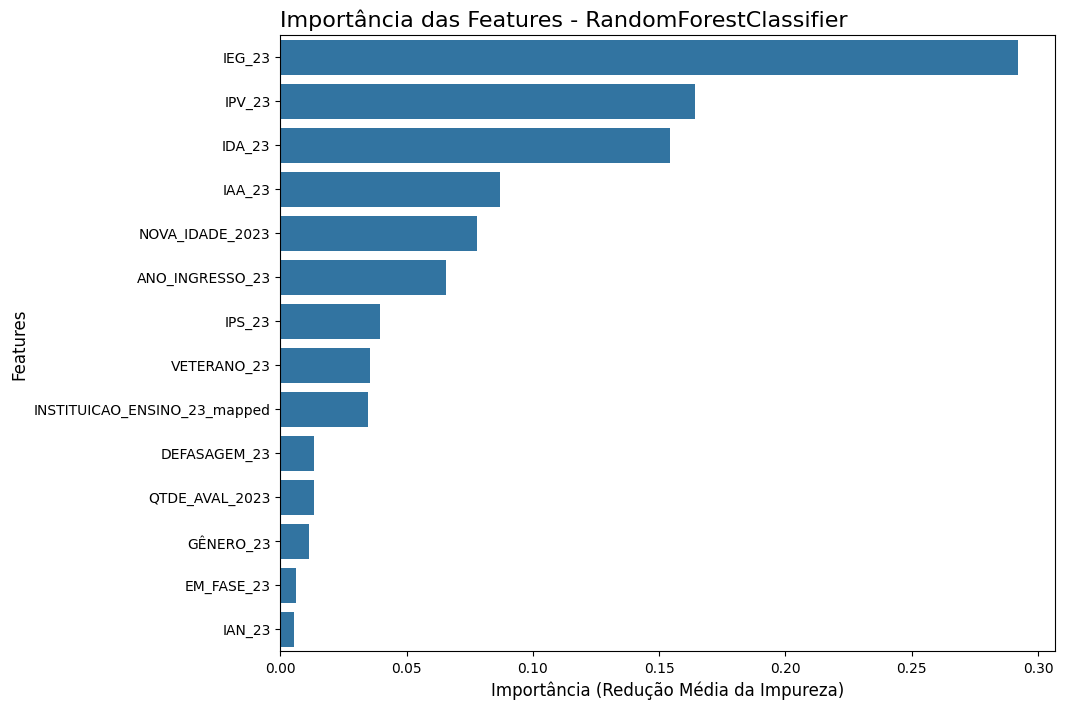

In [80]:
importances = model_rf.feature_importances_
feature_names = X_train.columns
feature_importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance_series, y=feature_importance_series.index)
plt.title('Importância das Features - RandomForestClassifier', fontsize=16, loc='left')
plt.xlabel('Importância (Redução Média da Impureza)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.show()

### SHAP Values

In [81]:
explainer = shap.TreeExplainer(model_rf)

shap_values = explainer.shap_values(X_test_df)

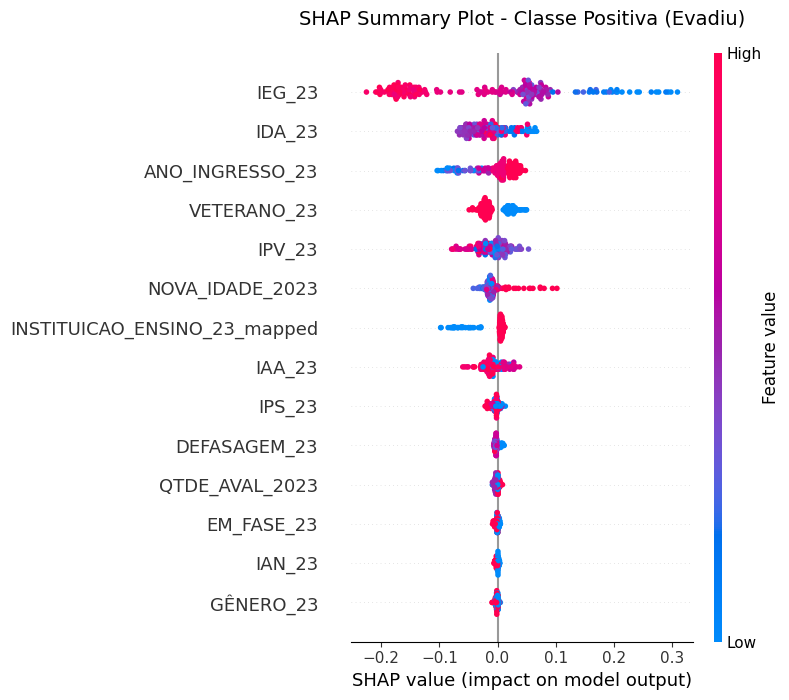

In [82]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,  
    plot_type="dot",  
    feature_names=X_test.columns.tolist(),
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot - Classe Positiva (Evadiu)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Modelagem - LightGBM

## Parâmetros e modelo

In [83]:
# Dicionário de parâmetros iniciais para LightGBM
RANDOM_STATE = 42

lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1,
    'min_data': 150,
}

lgbm_model = LGBMClassifier(**lgbm_params)

## Validação cruzada

In [84]:
results_lgb = perform_cross_validation(
    X_train=X_train,
    y_train=y_train,
    skf=skf,
    model=lgbm_model,
)


Processando Fold 1/5

Train      - Acc: 0.6932 | F1: 0.5486 | ROC-AUC: 0.7636
Validation - Acc: 0.5878 | F1: 0.3960 | ROC-AUC: 0.6364

Processando Fold 2/5

Train      - Acc: 0.6780 | F1: 0.5433 | ROC-AUC: 0.7592
Validation - Acc: 0.6757 | F1: 0.5000 | ROC-AUC: 0.6744

Processando Fold 3/5

Train      - Acc: 0.6746 | F1: 0.5472 | ROC-AUC: 0.7540
Validation - Acc: 0.5405 | F1: 0.3929 | ROC-AUC: 0.6249

Processando Fold 4/5

Train      - Acc: 0.6633 | F1: 0.5318 | ROC-AUC: 0.7434
Validation - Acc: 0.6122 | F1: 0.4865 | ROC-AUC: 0.7134

Processando Fold 5/5

Train      - Acc: 0.6717 | F1: 0.5446 | ROC-AUC: 0.7594
Validation - Acc: 0.5918 | F1: 0.3878 | ROC-AUC: 0.5932

✅ Validação Cruzada concluída!


In [85]:
print("\n--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---")

for metric_name in results_lgb['validation']:
    mean_train = np.mean(results_lgb['train'][metric_name])
    std_train = np.std(results_lgb['train'][metric_name])
    mean_val = np.mean(results_lgb['validation'][metric_name])
    std_val = np.std(results_lgb['validation'][metric_name])

    print(f"\nMétrica: {metric_name.replace('_', ' ').title()}")
    print(f"  - Treino     : {mean_train:.4f} ± {std_train:.4f}")
    print(f"  - Validação  : {mean_val:.4f} ± {std_val:.4f}")


--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---

Métrica: Accuracy
  - Treino     : 0.6762 ± 0.0098
  - Validação  : 0.6016 ± 0.0438

Métrica: F1 Score
  - Treino     : 0.5431 ± 0.0060
  - Validação  : 0.4326 ± 0.0497

Métrica: Recall
  - Treino     : 0.7474 ± 0.0148
  - Validação  : 0.5895 ± 0.0755

Métrica: Precision
  - Treino     : 0.4267 ± 0.0090
  - Validação  : 0.3430 ± 0.0428

Métrica: Log Loss
  - Treino     : 0.5966 ± 0.0062
  - Validação  : 0.6480 ± 0.0186

Métrica: Roc Auc
  - Treino     : 0.7559 ± 0.0070
  - Validação  : 0.6485 ± 0.0416

Métrica: Pr Auc
  - Treino     : 0.4992 ± 0.0194
  - Validação  : 0.3861 ± 0.0561


## Testando modelo

In [86]:
feature_names = X_train.columns

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [87]:
lgbm_model = LGBMClassifier(**lgbm_params)

print("Treinando o modelo final com os dados de treino completos...")
lgbm_model.fit(X_train_scaled, y_train) 

print("Avaliando o modelo no conjunto de teste...")
y_pred = lgbm_model.predict(X_test_scaled)
y_proba = lgbm_model.predict_proba(X_test_scaled)

Treinando o modelo final com os dados de treino completos...


Avaliando o modelo no conjunto de teste...


## Métricas e visualizações

In [88]:
# Extrair probabilidade da classe positiva (coluna 1)
y_proba_pos = y_proba[:, 1]

# Calcular métricas para classificação binária
test_metrics_lgb = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, pos_label=1),  
    'recall': recall_score(y_test, y_pred, pos_label=1),  # Sensibilidade
    'precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
    'log_loss': log_loss(y_test, y_proba),  
    'roc_auc': roc_auc_score(y_test, y_proba_pos),  
}

print("\n📊 MÉTRICAS NO CONJUNTO DE TESTE:")
print("="*50)
for name, value in test_metrics_lgb.items():
    print(f"  {name.replace('_', ' ').title():15s}: {value:.4f}")


📊 MÉTRICAS NO CONJUNTO DE TESTE:
  Accuracy       : 0.6432
  F1 Score       : 0.4844
  Recall         : 0.6458
  Precision      : 0.3875
  Log Loss       : 0.6098
  Roc Auc        : 0.7188


### Scatter plot do logloss

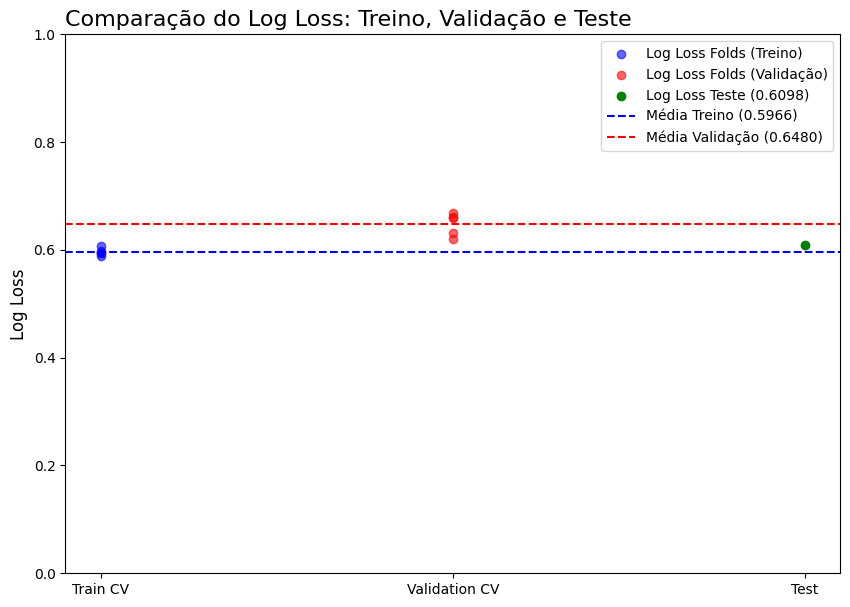

In [89]:
plt.figure(figsize=(10, 7))

labels = ['Train CV', 'Validation CV', 'Test']
train_losses = results_lgb['train']['log_loss']
val_losses = results_lgb['validation']['log_loss']
test_loss = test_metrics_lgb['log_loss']

plt.scatter(y=train_losses, x=['Train CV']*N_SPLITS, color='blue', alpha=0.6, label='Log Loss Folds (Treino)')
plt.scatter(y=val_losses, x=['Validation CV']*N_SPLITS, color='red', alpha=0.6, label='Log Loss Folds (Validação)')
plt.scatter([2], [test_loss], color='green', label=f'Log Loss Teste ({test_loss:.4f})')

mean_train_loss = np.mean(train_losses)
mean_val_loss = np.mean(val_losses)

plt.axhline(y=mean_train_loss, color='blue', linestyle='--', label=f'Média Treino ({mean_train_loss:.4f})')
plt.axhline(y=mean_val_loss, color='red', linestyle='--', label=f'Média Validação ({mean_val_loss:.4f})')

plt.title('Comparação do Log Loss: Treino, Validação e Teste', fontsize=16, loc='left')
plt.ylabel('Log Loss', fontsize=12)

plt.xticks(range(len(labels)), labels)
plt.ylim(0, 1)
plt.legend()
plt.grid(False)
plt.show()

### Matriz de confusão

In [90]:
list(order_by_label)
order_by_label = ['Não evadiu', 'Evadiu']

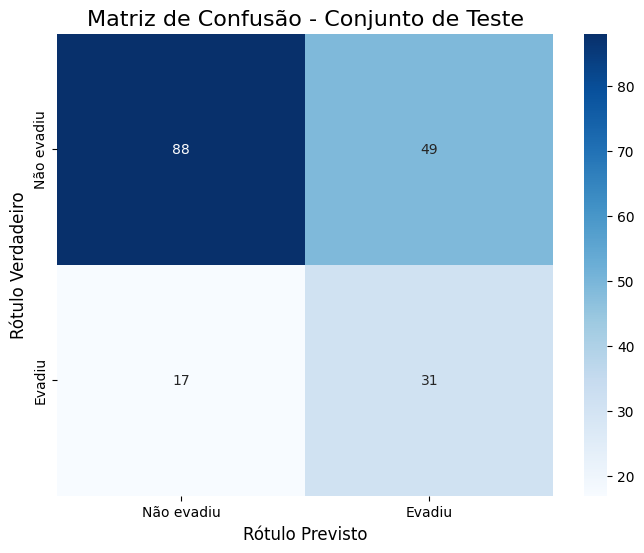

In [91]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(order_by_label), yticklabels=list(order_by_label))
plt.title('Matriz de Confusão - Conjunto de Teste', fontsize=16)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.show()

In [92]:
print(classification_report(y_test, y_pred, target_names=[str(c) for c in list(order_by_label)], digits=4))

              precision    recall  f1-score   support

  Não evadiu     0.8381    0.6423    0.7273       137
      Evadiu     0.3875    0.6458    0.4844        48

    accuracy                         0.6432       185
   macro avg     0.6128    0.6441    0.6058       185
weighted avg     0.7212    0.6432    0.6643       185



### Feature importance

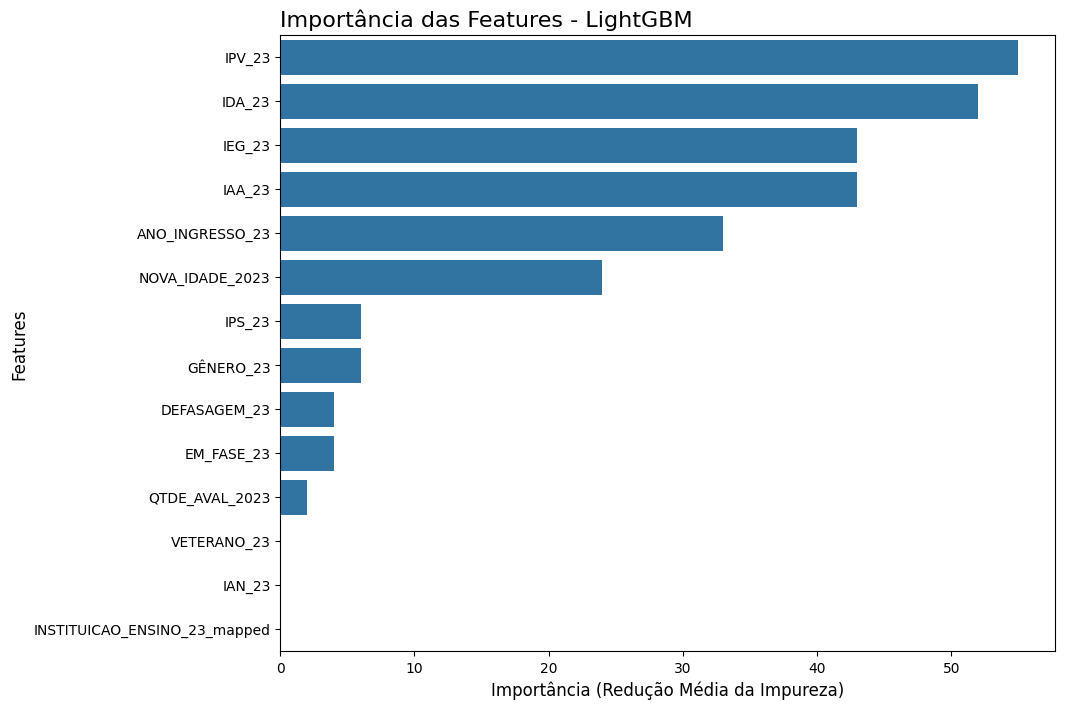

In [93]:
importances = lgbm_model.feature_importances_
feature_names = X_train.columns
feature_importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance_series, y=feature_importance_series.index)
plt.title('Importância das Features - LightGBM', fontsize=16, loc='left')
plt.xlabel('Importância (Redução Média da Impureza)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.show()

### SHAP Values

In [94]:
explainer = shap.TreeExplainer(lgbm_model)

shap_explanation = explainer(X_test_scaled)

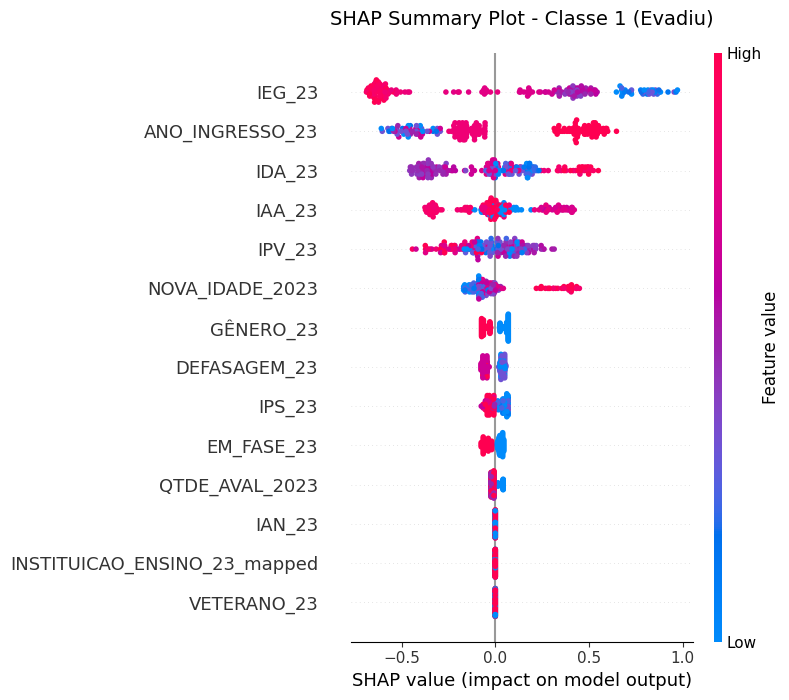

In [95]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_explanation,
    X_test_scaled,
    show=False
)
plt.title('SHAP Summary Plot - Classe 1 (Evadiu)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()